
# What Drives Airbnb Pricing in Vienna?
### Combining structured listing data with guest review text to model price and understand what guests notice at each price point

**Author:** Olga Nureeva · [LinkedIn](https://linkedin.com/in/olga-nureeva) · [GitHub](https://github.com/Onureeva)

---

**Business question.** Treat a short-term rental as an investment asset rather than a listing. Someone acquiring or repositioning a Vienna property faces two decisions: **which price tier this asset can realistically compete in**, and **what to spend money on to get there**. Both decisions turn on a distinction the structured data alone cannot make — some attributes are bought with the property and fixed at the moment of purchase, while others can be improved afterwards with capital.

Guest review text is where that distinction becomes visible. Reviews record what guests at each price point actually noticed and cared about, which is a different question from what the listing objectively contains. So this project asks two things: whether review text carries pricing signal beyond the structured fields, and — more usefully for an investor — **what each price tier's guests emphasise, and therefore which of those things can be changed and which cannot**.

**Data.** [Inside Airbnb](https://insideairbnb.com/get-the-data/) — Vienna, Austria, snapshot of 14 September 2025. Two sources: `listings.csv.gz` (property attributes and price) and `reviews.csv.gz` (guest review text). After cleaning and removing listings with missing prices, the modelling set is **8,139 unique listings**, each paired with the concatenated text of its 10 most recent reviews.

**Headline results.**

| Model | R² (log price) | MAE | Median AE |
|---|---:|---:|---:|
| Median baseline | — | 80.06 USD| 30.00 USD |
| Structural features only | 0.381 | 66.83 USD | 21.33 USD |
| Structural + NLP features | **0.410** | **65.84 USD** | 21.48 USD |

Review text adds real but modest predictive value: approximately **+0.03 R² and 0.99 USD lower mean absolute error**. Structural listing characteristics remain the main source of predictive power, while review text provides incremental signal and helps explain differences in market positioning.

Where the text earns its place is in explaining *why*, and that is where the decision value sits. Review topics shift systematically across price tiers (Kruskal–Wallis, Holm-adjusted p < 0.001 for all four), and they split cleanly into what an investor buys and what an investor can build.

**Method.** EDA and cleaning → TF-IDF and n-grams → topic modelling compared across LDA, NMF, and LSA (NMF selected for topic separability) → DistilBERT sentiment scoring → feature engineering → Ridge regression evaluated against a median baseline → price-segment analysis with non-parametric significance testing.

**How to run.** Python 3.10+, dependencies in `requirements.txt`. Listings and reviews download directly from Inside Airbnb; the cached DistilBERT sentiment scores are in `data/listing_sentiment.csv`. Run cells top to bottom. Sentiment scoring is the only expensive step and is cached — the code that produced it is preserved and documented in the sentiment section.

**A note on an error I found and corrected.** An earlier version of this analysis merged listings against individual reviews rather than against per-listing aggregated text. This duplicated each listing up to ten times, so a random train/test split placed the same listing — with the same price and the same structural features — on both sides of the split. Reported R² was 0.62. After correcting the merge to one row per listing, honest R² is 0.410. The lower number is the real one. I have left this note in because catching it mattered more to the quality of the work than the metric did.


# 1. Exploratory Data Analysis

### Importing the required Libraries and the Dataset

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# import datasets
listings_url = 'https://data.insideairbnb.com/austria/vienna/vienna/2025-09-14/data/listings.csv.gz'

reviews_url = 'https://data.insideairbnb.com/austria/vienna/vienna/2025-09-14/data/reviews.csv.gz'

# Load the datasets into DataFrames
listings_df = pd.read_csv(listings_url, compression='gzip',encoding="mac_roman")

reviews_df = pd.read_csv(reviews_url, compression='gzip')



## Data Cleaning (Reviews Dataset)

In [3]:
#Please use the link below to access the colab file for the reviews cleaning and analysis.
#This was done separately as the reveiws data loads very slowly.
# https://drive.google.com/file/d/1izE0iuUXv55_1LFI0viDYRIOTUWdJ_Mb/view?usp=sharing


## Data Cleaning (Listing Dataset)

In [4]:
#Listing the top 5 rows of tthe dataset
listings_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40625,https://www.airbnb.com/rooms/40625,20250914152932,2025-09-14,city scrape,"Near Palace Sch√∂nbrunn, Apt. 1",Welcome to my Apt. 1!<br /><br />This is a 2be...,The neighbourhood offers plenty of restaurants...,https://a0.muscache.com/pictures/11509144/d55c...,175131,...,4.94,4.61,4.73,NaN,f,14,13,1,0,1.22
1,51287,https://www.airbnb.com/rooms/51287,20250914152932,2025-09-14,city scrape,little studio- next to citycenter- wifi- nice ...,small studio in new renovated old house and ve...,The neighbourhood has a lot of very nice littl...,https://a0.muscache.com/pictures/25163038/1c4e...,166283,...,4.95,4.87,4.59,NaN,f,2,2,0,0,2.15
2,109679,https://www.airbnb.com/rooms/109679,20250914152932,2025-09-14,city scrape,Near Palace Sch√∂nbrunn - Apt. 4,Studio apartment for 4 persons:<br />- Bunk be...,The neighbourhood offers plenty of restaurants...,https://a0.muscache.com/pictures/1982234/1fc34...,175131,...,4.92,4.66,4.82,NaN,f,14,13,1,0,0.93
3,114505,https://www.airbnb.com/rooms/114505,20250914152932,2025-09-14,city scrape,"Near Palace Sch√∂nbrunn, Apt. 5",Studio apartment for 4 persons:<br />- Bunk be...,The neighbourhood offers plenty of restaurants...,https://a0.muscache.com/pictures/11536257/9065...,175131,...,4.96,4.71,4.80,NaN,f,14,13,1,0,0.71
4,131628,https://www.airbnb.com/rooms/131628,20250914152932,2025-09-15,previous scrape,"Holiday Apartment ""Modern Vienna""",Modern ambiance in a turn of the century house...,"Bakerys, Viennese wine taverns (‚ÄúHeurige‚Äú)...",https://a0.muscache.com/pictures/35385584/a900...,647465,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN


In [5]:
#Checking the number of rows and columns in the dataset
listings_df.shape

(14123, 79)

In [6]:
# Listing the names of all the columns.
listings_df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [7]:
listings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14123 entries, 0 to 14122
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            14123 non-null  int64  
 1   listing_url                                   14123 non-null  object 
 2   scrape_id                                     14123 non-null  int64  
 3   last_scraped                                  14123 non-null  object 
 4   source                                        14123 non-null  object 
 5   name                                          14123 non-null  object 
 6   description                                   13704 non-null  object 
 7   neighborhood_overview                         6407 non-null   object 
 8   picture_url                                   14122 non-null  object 
 9   host_id                                       14123 non-null 

In [8]:
# Checking Duplicate rows
listings_df[listings_df.duplicated()]
# to remove the duplicate columns
# listings_df.drop_duplicates(inplace = True)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [9]:
missing_perc = listings_df.isna().sum()/len(listings_df) * 100
# Filtering for values > 0 and sorting them from highest to lowest
missing_perc[missing_perc > 0].sort_values(ascending=False)

,0
calendar_updated,100.000000
license,100.000000
neighbourhood_group_cleansed,100.000000
host_neighbourhood,62.777030
neighborhood_overview,54.634285
neighbourhood,54.634285
host_about,51.547122
host_location,27.062239
estimated_revenue_l365d,27.026836
price,27.026836


Since the number of columns are a lot, we eliminate the the text based columns which have no relation to the analysis.

Since the price Column has around 27% of the missing values, removing the rows would be a better alternative as populating the missing rows with mean/median/mode will not help us in our analysis (the price of each property is different)

In [10]:
listings_df.dropna(subset=['price'], inplace = True)

In [11]:
missing_perc1 = listings_df.isna().sum()/len(listings_df) * 100
# Filtering for values > 0 and sorting them from highest to lowest
missing_perc1[missing_perc1 > 0].sort_values(ascending=False)

,0
calendar_updated,100.000000
neighbourhood_group_cleansed,100.000000
license,100.000000
host_neighbourhood,68.397050
neighborhood_overview,54.230545
neighbourhood,54.230545
host_about,49.019988
host_location,28.827867
review_scores_value,13.661944
reviews_per_month,13.661944


In [12]:
# Dropping columns more than 50% of missing values.
# (calendar_updated, neighbourhood_group_cleansed, license, host_neighbourhood, neighborhood_overview, neighbourhood, host_about)
Columns_to_Drop = missing_perc1[missing_perc1 > 40].index.tolist()
listings_df.drop(columns = Columns_to_Drop, inplace = True)

In [13]:
# Dropping the columns which are irrelavant to our analysis.
Columns_to_Drop1 = ['listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'calendar_last_scraped','bathrooms_text']

listings_df.drop(columns = Columns_to_Drop1, inplace = True)

In [14]:
listings_df.isna().mean()*100

,0
id,0.000000
neighbourhood_cleansed,0.000000
latitude,0.000000
longitude,0.000000
property_type,0.000000
room_type,0.000000
accommodates,0.000000
bathrooms,0.029109
bedrooms,0.329905
beds,0.048515


In [15]:
#Dropping the tiny number of rows with missing bed/bath values
listings_df.dropna(subset=['bathrooms'], inplace = True)
listings_df.dropna(subset=['bedrooms'], inplace = True)
listings_df.dropna(subset=['beds'], inplace = True)

<Axes: >

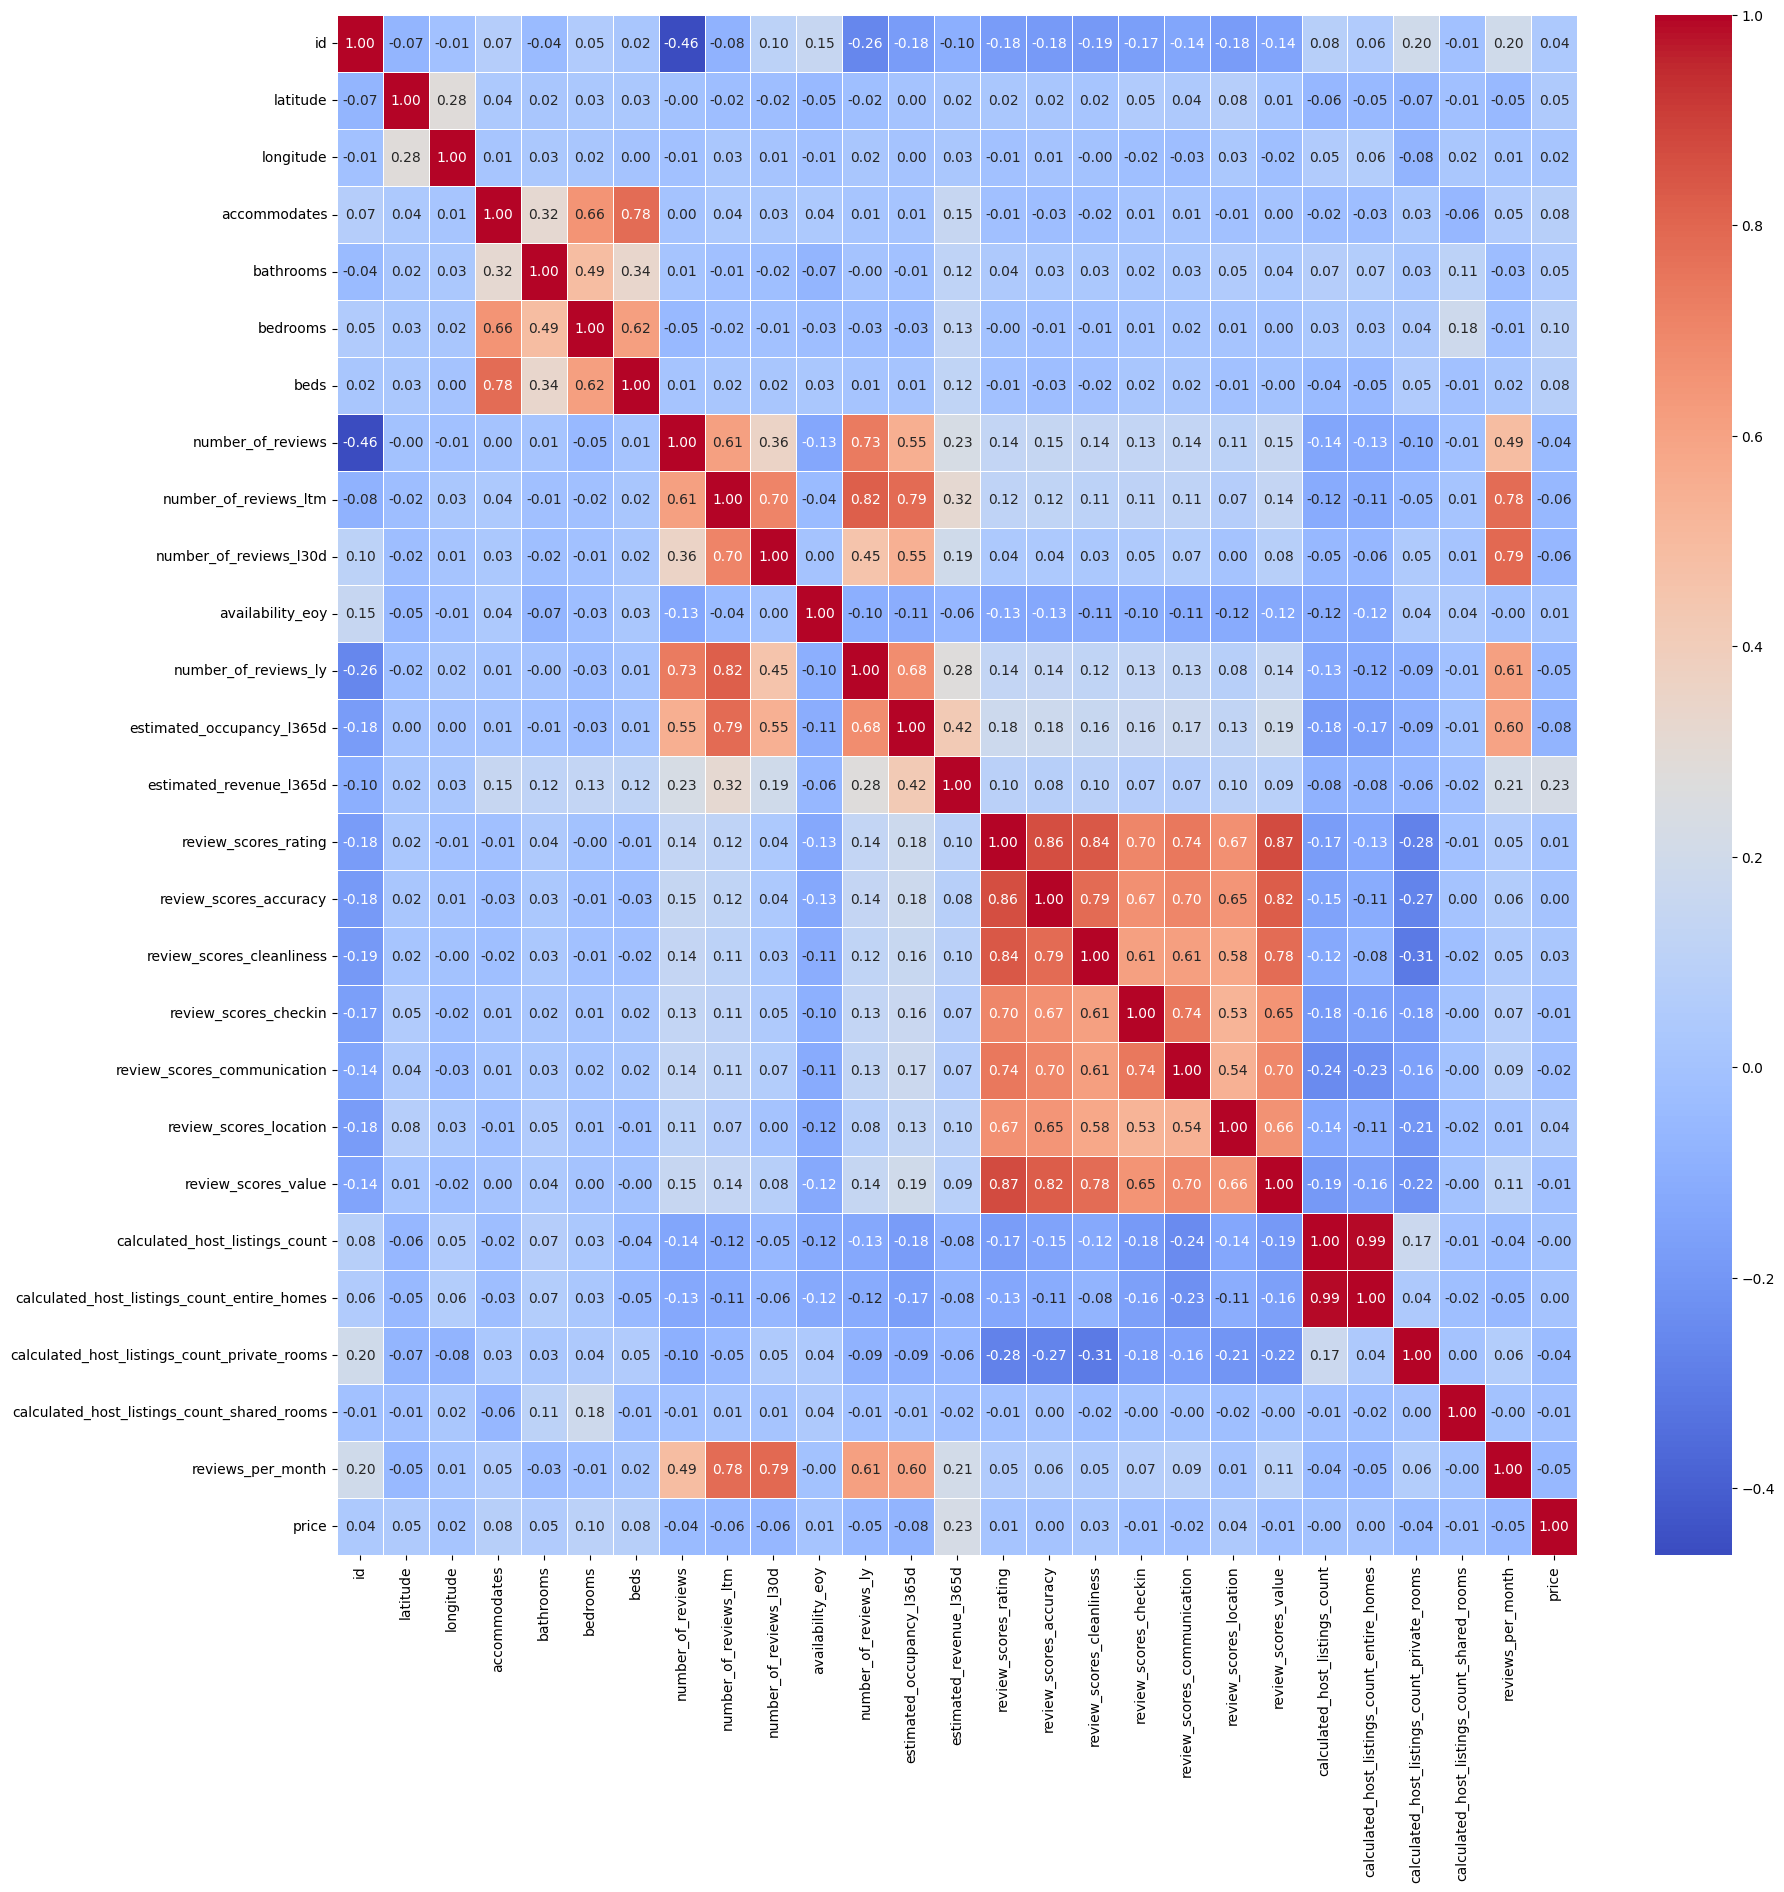

In [16]:
import seaborn as sns

#Converts price to an integer.
listings_df['price'] = listings_df['price'].str.replace(',', '').str.replace('$', '').str.replace('.00', '').astype(int)

#Separate numeric columns
num_cols = ['id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds','number_of_reviews',
'number_of_reviews_ltm',
'number_of_reviews_l30d',
'availability_eoy',
'number_of_reviews_ly',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin'	,
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month','price',]


#Generating a correlation heatmap
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(listings_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, fmt='.2f')




The review_scores columns are highly correlated, and reducing them will be important for feature selection. Number_of_reviews, host_listings_count, and accomodates should also be considered.

In [17]:
#Removing some of the highly correlated columns
Columns_to_Drop2 = ['review_scores_accuracy',
'number_of_reviews_ltm',
'review_scores_cleanliness',
'review_scores_checkin'	,
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'number_of_reviews',
'number_of_reviews_l30d',
'number_of_reviews_ly',
'availability_eoy',
'reviews_per_month',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',]

listings_df.drop(columns = Columns_to_Drop2, inplace = True)

In [18]:
print("------------")
# Checking percent of missing values for column.
missing_perc1 = listings_df.isna().sum()/len(listings_df) * 100
print(missing_perc1)

------------
id                                               0.000000
neighbourhood_cleansed                           0.000000
latitude                                         0.000000
longitude                                        0.000000
property_type                                    0.000000
room_type                                        0.000000
accommodates                                     0.000000
bathrooms                                        0.000000
bedrooms                                         0.000000
beds                                             0.000000
amenities                                        0.000000
price                                            0.000000
first_review                                    13.522993
last_review                                     13.522993
review_scores_rating                            13.522993
instant_bookable                                 0.000000
calculated_host_listings_count_private_rooms     0.000000
c

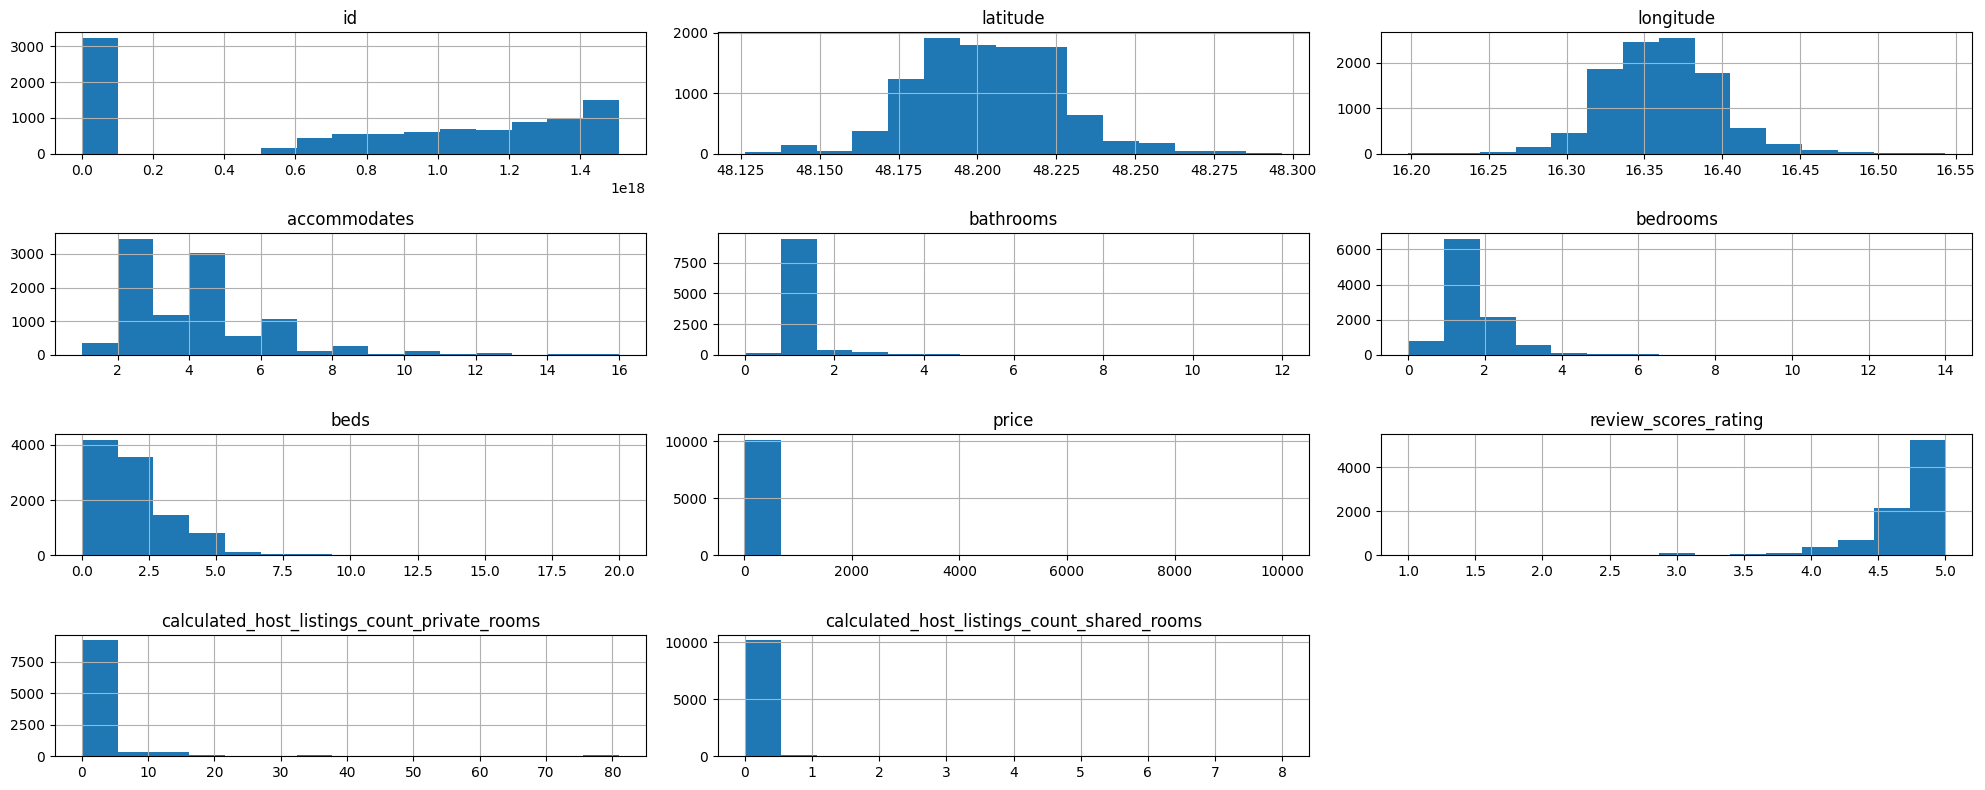

In [19]:
num_cols = [
    'id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'price', 'review_scores_rating', 'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms'
]

#Histogram of numeric columns
listings_df[num_cols].hist(bins=15, figsize=(20,8))
plt.tight_layout()
plt.show()

In [20]:
listings_df[num_cols].describe()


,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
count,1.026400e+04,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,10264.000000,8876.000000,10264.000000,10264.000000
mean,7.781746e+17,48.203342,16.361295,3.669232,1.182970,1.313426,2.032443,155.596454,4.668018,2.652572,0.026208
std,5.732235e+17,0.023183,0.036093,1.980565,0.482863,0.884035,1.355542,523.179107,0.469546,9.934694,0.332985
min,4.062500e+04,48.126310,16.198216,1.000000,0.000000,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000
25%,4.537821e+07,48.187703,16.336535,2.000000,1.000000,1.000000,1.000000,66.000000,4.590000,0.000000,0.000000
50%,9.375498e+17,48.202245,16.360890,4.000000,1.000000,1.000000,2.000000,93.000000,4.790000,0.000000,0.000000
75%,1.295753e+18,48.218890,16.383436,4.000000,1.000000,2.000000,2.000000,141.000000,4.930000,0.000000,0.000000
max,1.508944e+18,48.296630,16.543390,16.000000,12.000000,14.000000,20.000000,10000.000000,5.000000,81.000000,8.000000


#Uploading cleaned reviews

In [21]:
# Load preprocessed reviews from the project repository

cleaned_reviews_url = (
    "https://raw.githubusercontent.com/"
    "Onureeva/airbnb-vienna-nlp-pricing/main/"
    "data/cleaned_reviews.csv.gz"
)

df_cleaned = pd.read_csv(
    cleaned_reviews_url,
    compression="gzip"
)

print(f"Cleaned reviews shape: {df_cleaned.shape}")
df_cleaned.head()

Cleaned reviews shape: (319614, 7)


,listing_id,date,comments,language,comments_soft,comments_clean,review_length
0,40625,2010-08-04,Ingela is a superb host. She personally welco...,en,Ingela is a superb host. She personally welcom...,ingela is a superb host she personally welcome...,80
1,40625,2010-10-03,Ingela was a perfect host! She gave great dire...,en,Ingela was a perfect host! She gave great dire...,ingela was a perfect host she gave great direc...,61
2,40625,2011-03-22,Our stay in Vienna with Ingela could not have ...,en,Our stay in Vienna with Ingela could not have ...,our stay in vienna with ingela could not have ...,103
3,40625,2011-09-21,Our stay in the beautiful city of Vienna was g...,en,Our stay in the beautiful city of Vienna was g...,our stay in the beautiful city of vienna was g...,98
4,40625,2011-10-01,We really enjoyed our visit and loved the very...,en,We really enjoyed our visit and loved the very...,we really enjoyed our visit and loved the very...,26


In [22]:
# Fix encoding artifacts in Vienna neighbourhood names
listings_df["neighbourhood_cleansed"] = (
    listings_df["neighbourhood_cleansed"]
    .str.replace("¬ü", "ü", regex=False)
    .str.replace("¬ö", "ö", regex=False)
    .str.replace("¬ä", "ä", regex=False)
    .str.replace("¬ß", "ß", regex=False)
)

In [23]:
listings_df["neighbourhood_cleansed"].unique()

array(['Rudolfsheim-Fünfhaus', 'Leopoldstadt', 'Hernals', 'Wieden',
       'Margareten', 'Innere Stadt', 'Landstraße', 'Mariahilf',
       'Simmering', 'Neubau', 'Brigittenau', 'Ottakring', 'Josefstadt',
       'Penzing', 'Floridsdorf', 'Alsergrund', 'Donaustadt', 'Währing',
       'Meidling', 'Döbling', 'Favoriten', 'Hietzing', 'Liesing'],
      dtype=object)

# Filtering By Date

In [24]:
df_cleaned.head()
df_cleaned.shape

(319614, 7)

In [25]:
#Filtering for the last 10 reviews per listing, and concatenating them

print('Pre-sort')
print(df_cleaned.nunique())



# Code from class tutorial
# Get the last 10 reviews per listing
latest_reviews = (
    df_cleaned.sort_values(['listing_id', 'date'], ascending=[True, False])
      .groupby('listing_id')
      .head(10)
)


Pre-sort
listing_id         10850
date                4908
comments          315742
language               1
comments_soft     315677
comments_clean    312672
review_length        485
dtype: int64


In [26]:
# Concatenate the last 10 reviews into one row per listing
listing_texts = (
    latest_reviews
    .groupby("listing_id")
    .agg(
        combined_reviews=(
            "comments",
            lambda x: " ".join(x.astype(str))
        ),
        comments_clean=(
            "comments_clean",
            lambda x: " ".join(x.astype(str))
        ),
        comments_soft=(
            "comments_soft",
            lambda x: " ".join(x.astype(str))
        )
    )
    .reset_index()
)

# Check the shape of the new DataFrame
listing_texts.shape
print('Post-sort')
print(listing_texts.nunique())

listing_texts.head()

Post-sort
listing_id          10850
combined_reviews    10843
comments_clean      10837
comments_soft       10843
dtype: int64


,listing_id,combined_reviews,comments_clean,comments_soft
0,40625,We had a wonderful stay at this apartment. The...,we had a wonderful stay at this apartment the ...,We had a wonderful stay at this apartment. The...
1,51287,I stayed for two months in this place. The ins...,i stayed for two months in this place the inst...,I stayed for two months in this place. The ins...
2,109679,We had a nice stay. The apartment was easy to ...,we had a nice stay the apartment was easy to f...,We had a nice stay. The apartment was easy to ...
3,114505,"Ingela is super nice and thoughtful, the place...",ingela is super nice and thoughtful the place ...,"Ingela is super nice and thoughtful, the place..."
4,169672,Astrid was a wonderful host with a beautiful s...,astrid was a wonderful host with a beautiful s...,Astrid was a wonderful host with a beautiful s...


# Merging the Reviews and Listings Data

In [27]:
#Merging the two dataframes using the common listing ID, then checking the head and shape.
merged_df = pd.merge(
    listings_df,
    listing_texts,
    left_on='id',
    right_on='listing_id',
    how='inner'
).drop(columns=['id'])

print(merged_df.shape)
print("Unique listings:", merged_df["listing_id"].nunique())
print("Duplicate listing IDs:", merged_df["listing_id"].duplicated().sum())
print(merged_df.head())



(8141, 21)
Unique listings: 8141
Duplicate listing IDs: 0
  neighbourhood_cleansed  latitude  longitude                property_type  \
0   Rudolfsheim-Fünfhaus  48.18434   16.32701           Entire rental unit   
1           Leopoldstadt  48.21778   16.37847           Entire rental unit   
2   Rudolfsheim-Fünfhaus  48.18467   16.32795           Entire rental unit   
3   Rudolfsheim-Fünfhaus  48.18445   16.32722           Entire rental unit   
4                 Wieden  48.19527   16.36374  Private room in rental unit   

         room_type  accommodates  bathrooms  bedrooms  beds  \
0  Entire home/apt             6        1.0       2.0   3.0   
1  Entire home/apt             2        1.0       0.0   2.0   
2  Entire home/apt             4        1.0       0.0   4.0   
3  Entire home/apt             4        1.0       0.0   3.0   
4     Private room             2        1.0       1.0   1.0   

                                           amenities  ...  first_review  \
0  ["Smoke alarm", 

In [28]:
print(merged_df.shape)
print("Unique listings:", merged_df["listing_id"].nunique())
print("Duplicate listing IDs:", merged_df["listing_id"].duplicated().sum())

(8141, 21)
Unique listings: 8141
Duplicate listing IDs: 0


In [29]:
merged_df.isnull().sum()

,0
neighbourhood_cleansed,0
latitude,0
longitude,0
property_type,0
room_type,0
accommodates,0
bathrooms,0
bedrooms,0
beds,0
amenities,0


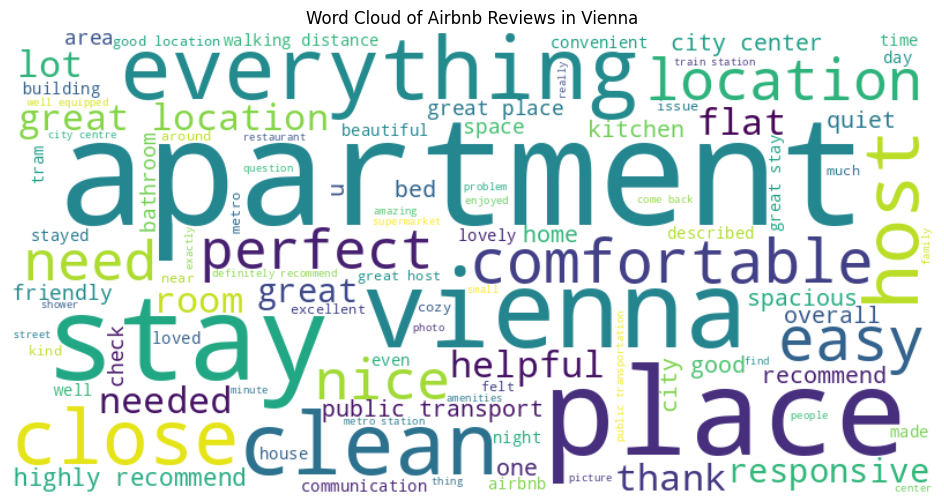

In [30]:
from wordcloud import WordCloud

# Use the text already cleaned in the preprocessing notebook
all_text = " ".join(
    merged_df["comments_clean"]
    .dropna()
    .astype(str)
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Airbnb Reviews in Vienna")
plt.show()

Text Preprocessing Raw reviews often contain punctuation, capitalization, numbers, and stopwords (common words like the, is, at). Before applying NLP techniques such as Bag-of-Words or TF-IDF, we need to clean and standardize the text.

In this step, we will:

Convert text to lowercase Remove punctuation and numbers Remove common stopwords (Optional) Apply stemming or lemmatization — reducing words to their root form (running → run)

Bag-of-Words (Word Counts) The Bag-of-Words model represents text by counting how many times each word appears.

It ignores word order, grammar, and context. Each document becomes a vector of word frequencies. While simple, it often works surprisingly well for tasks like sentiment classification or topic clustering. We will use CountVectorizer from scikit-learn to transform our Airbnb reviews into a document-term matrix.

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize vectorizer (limit vocab size for demo)
vectorizer = CountVectorizer(max_features=20, stop_words='english')

# Fit and transform cleaned reviews
bow_matrix = vectorizer.fit_transform(merged_df['comments_clean'])

# Convert to DataFrame for readability
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

print("Shape of BoW matrix:", bow_df.shape)
bow_df.head(10)

Shape of BoW matrix: (8141, 20)


,apartment,city,clean,close,comfortable,easy,good,great,helpful,host,location,nice,perfect,place,quiet,really,recommend,responsive,stay,vienna
0,9,1,3,0,4,2,1,4,1,4,5,1,3,3,1,2,4,2,7,3
1,8,3,2,2,0,1,5,11,4,3,5,7,1,4,3,3,3,2,4,3
2,5,0,4,2,2,1,2,4,1,5,0,1,1,4,0,3,2,1,6,4
3,14,2,6,3,1,4,2,7,3,3,5,5,2,4,0,1,3,0,9,3
4,0,1,0,3,1,1,3,5,2,4,5,1,2,7,1,2,5,3,6,5
5,5,6,2,6,1,4,0,6,0,2,5,3,1,8,2,2,3,3,6,4
6,8,0,1,2,1,0,1,4,1,2,6,0,4,2,3,0,1,0,1,1
7,10,2,3,4,3,2,1,7,1,2,4,3,2,3,3,1,0,3,1,0
8,7,1,3,3,3,3,0,3,0,0,0,1,3,8,1,1,4,0,10,4
9,1,1,1,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,2,1


TF-IDF (Term Frequency–Inverse Document Frequency) Bag-of-Words gives us raw counts of words, but it does not distinguish between common words (like room, place, stay) and more meaningful words.

TF-IDF improves on this by weighting words based on two factors:

Term Frequency (TF): How often a word appears in a single document. Inverse Document Frequency (IDF): How rare the word is across the entire collection of documents. Why it matters Words that are frequent in a single review but rare across all reviews (e.g., fireplace, mountain, cozy) receive higher importance. Very common words that appear in nearly every review (e.g., room, good, stay) are downweighted. Key Takeaway TF-IDF highlights the most distinctive words in reviews, giving us a more meaningful text representation for analysis and modeling.

We will now apply TF-IDF to our Airbnb sample reviews and inspect the top weighted words.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Apply TF-IDF
tfidf = TfidfVectorizer(max_features=1000, max_df=0.85, min_df=15, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(merged_df['comments_clean'])

# Convert to DataFrame for inspection
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Show top rows
print("TF-IDF matrix (first 5 rows):")
display(tfidf_df.head())

TF-IDF matrix (first 5 rows):


,able,absolutely,ac,access,access city,access public,accessible,accommodating,accommodation,accomodation,...,wonderful host,wonderful stay,work,worked,working,works,worth,wouldnt,year,youre
0,0.000000,0.0,0.072878,0.000000,0.0,0.0,0.070774,0.000000,0.000000,0.0,...,0.000000,0.067970,0.0,0.073817,0.0,0.000000,0.000000,0.0,0.0,0.000000
1,0.054865,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.073148,0.000000,0.0,0.0,0.058377
2,0.080642,0.0,0.000000,0.000000,0.0,0.0,0.082166,0.000000,0.073708,0.0,...,0.107183,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000
3,0.062385,0.0,0.130908,0.000000,0.0,0.0,0.000000,0.065818,0.000000,0.0,...,0.000000,0.000000,0.0,0.066297,0.0,0.000000,0.000000,0.0,0.0,0.000000
4,0.073022,0.0,0.000000,0.052421,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.097055,0.071455,0.0,0.000000,0.0,0.000000,0.148531,0.0,0.0,0.077696


Words like "comfortable", "great", "host", "location", "station", "city", "recommend" tend to have higher TF-IDF scores in specific listings. This indicates these words are particularly important or distinctive for those reviews, even if they may not appear frequently across all listings.

##N-grams
N-grams capture phrases and context, making them more informative for understanding text compared to isolated words. They are especially useful in sentiment analysis, topic modeling, and search engines where meaning depends on word combinations.

In the next step, we will generate bigrams and trigrams from the Vienna Airbnb reviews and explore the most common ones.

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

# Use bigrams and trigrams (n=2 and n=3)
ngram_vectorizer = CountVectorizer(ngram_range=(2,3), stop_words='english', max_features=30)

# Fit and transform on the cleaned reviews
X_ngrams = ngram_vectorizer.fit_transform(merged_df['comments_clean'])

# Convert to dataframe
ngrams_df = pd.DataFrame(X_ngrams.toarray(), columns=ngram_vectorizer.get_feature_names_out())

# Get the top n-grams by summing across all documents
top_ngrams = ngrams_df.sum().sort_values(ascending=False).head(20)

print("Top 20 most frequent bigrams and trigrams:")
print(top_ngrams)

Top 20 most frequent bigrams and trigrams:
great location           4329
highly recommend         3730
public transport         3603
place stay               3121
city center              3102
great place              2823
great stay               2592
walking distance         2587
apartment clean          2434
stay vienna              2251
good location            2078
enjoyed stay             2024
definitely recommend     1845
great host               1836
recommend place          1788
city centre              1743
apartment great          1729
public transportation    1717
stay apartment           1635
train station            1578
dtype: int64


In [34]:
# Define functions to create plots

import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud

# Function to plot the top words for each topic
def plot_top_words(model, feature_names, n_top_words=10, title='Top words per topic'):
    fig, axes = plt.subplots(1, model.n_components, figsize=(15, 5), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]
        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f'Topic {topic_idx+1}', fontdict={'fontsize': 10})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=10)
    plt.suptitle(title, fontsize=12)
    plt.subplots_adjust(top=0.85, wspace=0.3)
    plt.show()


# Function to generate word clouds for each topic
def plot_word_clouds(model, feature_names, n_top_words=30):
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = {feature_names[i]: topic[i] for i in top_features_ind}
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_features)
        plt.figure()
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Topic {topic_idx+1} Word Cloud', fontsize=16)
        plt.show()

##Topic modeling
Latent Dirichlet Allocation (LDA) Treats each document as a mixture of topics. Each topic is represented as a distribution of words. Helps discover interpretable themes in text.

In [35]:
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD

In [36]:
#LDA
# Set the number of topics
n_topics = 4

# Create and fit the LDA model
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_model.fit(bow_matrix)
#lda_model.fit(X_tfidf)

# Extract the top words from each topic
terms = vectorizer.get_feature_names_out()
lda_topics = {}

for index, topic in enumerate(lda_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    lda_topics[f"Topic {index+1}"] = top_words

# Print the LDA topics
print("LDA Topics:")
for topic, words in lda_topics.items():
    print(f"{topic}: {', '.join(words)}")

LDA Topics:
Topic 1: great, apartment, stay, location, clean, place, comfortable, nice, close, easy
Topic 2: apartment, location, great, good, host, stay, vienna, nice, place, close
Topic 3: apartment, stay, vienna, clean, place, city, easy, really, nice, great
Topic 4: place, stay, great, host, nice, clean, recommend, good, location, helpful


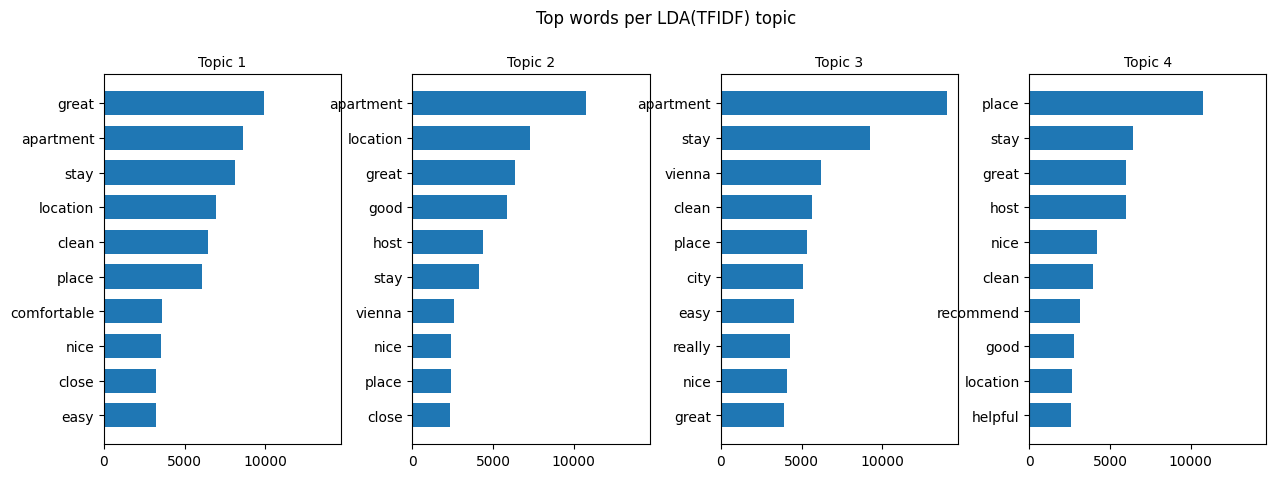

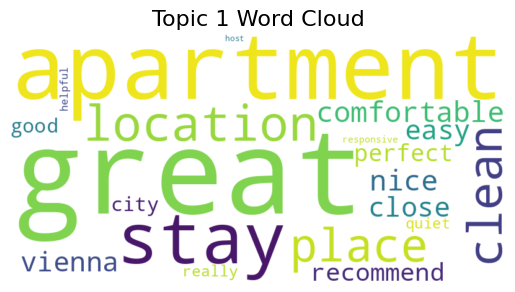

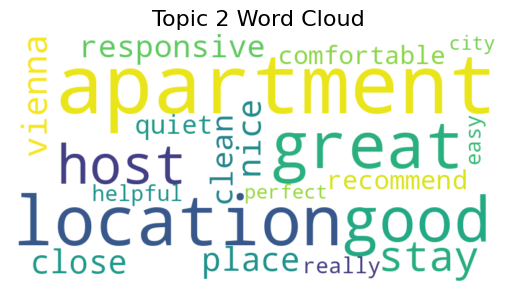

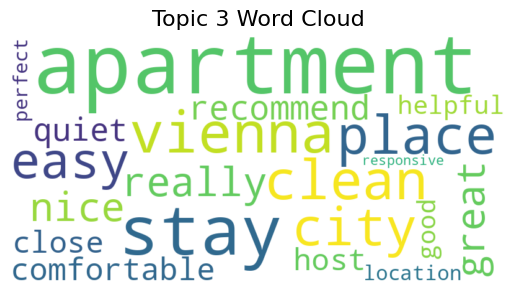

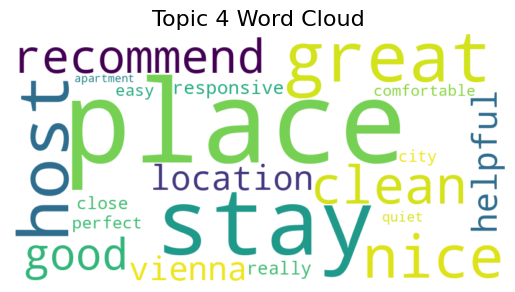

In [37]:
plot_top_words(lda_model, terms, n_top_words=10, title='Top words per LDA(TFIDF) topic')
plot_word_clouds(lda_model, terms)

2) Non-negative Matrix Factorization (NMF)
Decomposes the TF-IDF matrix into smaller components. Each component (topic) is described by the top keywords. Works well for short and interpretable topics.

In [38]:
# Create and fit the NMF model
nmf_model = NMF(n_components=n_topics, random_state=42)
nmf_model.fit(X_tfidf)

# Extract the top words from each topic
nmf_topics = {}
terms=tfidf.get_feature_names_out()
for index, topic in enumerate(nmf_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    nmf_topics[f"Topic {index+1}"] = top_words

# Print the NMF topics
print("NMF Topics:")
for topic, words in nmf_topics.items():
    print(f"{topic}: {', '.join(words)}")

NMF Topics:
Topic 1: apartment, stay, vienna, recommend, home, comfortable, highly, beautiful, quiet, walk
Topic 2: apartment, room, good, bathroom, shower, bed, kitchen, didnt, door, night
Topic 3: place, nice, stay, clean, good, close, place stay, really, easy, host
Topic 4: great, location, great location, stay, place, great place, apartment, apartment great, host, great stay


/usr/local/lib/python3.13/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


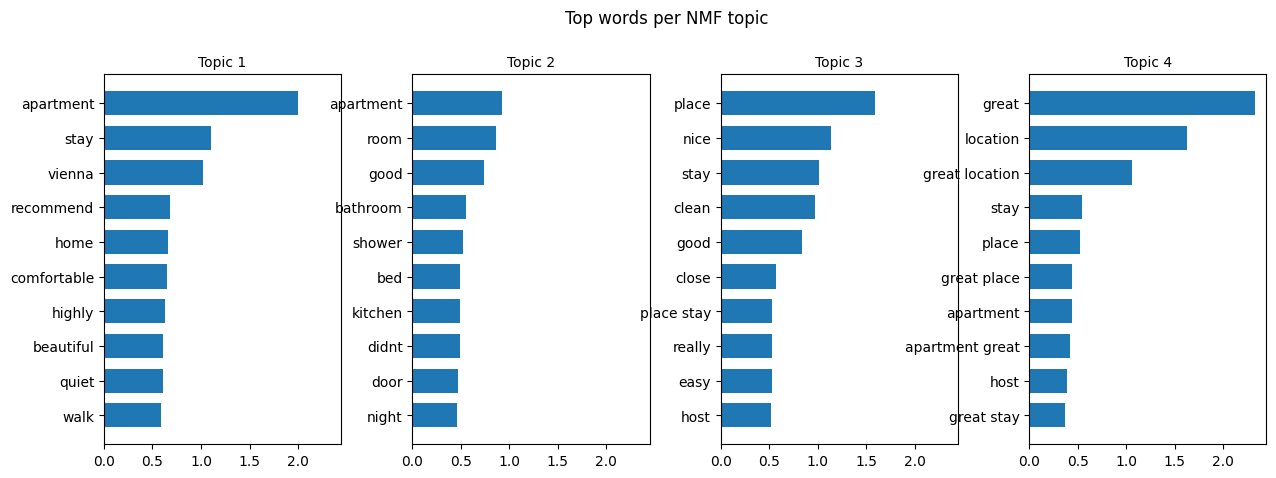

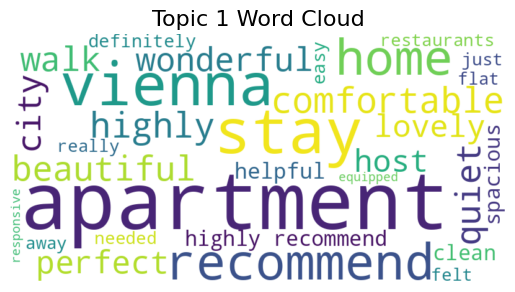

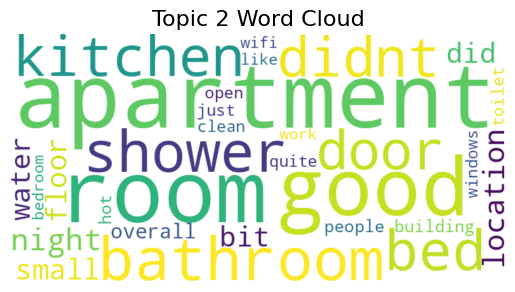

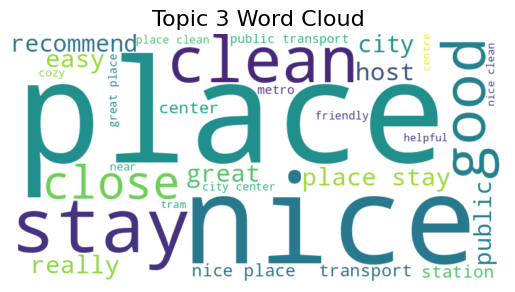

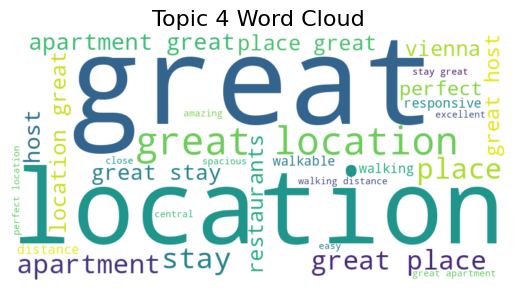

In [39]:
# NMF topic plots

plot_top_words(nmf_model, terms, n_top_words=10, title='Top words per NMF topic')
plot_word_clouds(nmf_model, terms)

##Latent Semantic Analysis (LSA)

Uses Singular Value Decomposition (SVD) to identify underlying structures in

Captures broader word associations but can be harder to interpret.

In [40]:
#Fit the LSA model
lsa_model = TruncatedSVD(n_components=n_topics, random_state=42)
lsa_model.fit(X_tfidf)


# Extract the top words for each topic
terms = tfidf.get_feature_names_out()
lsa_topics = {}

for index, topic in enumerate(lsa_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:][::-1]]  # Get top 10 words and reverse order
    lsa_topics[f"Topic {index+1}"] = top_words

# Print the LSA topics
print("LSA Topics:")
for topic, words in lsa_topics.items():
    print(f"{topic}: {', '.join(words)}")

LSA Topics:
Topic 1: apartment, stay, great, place, location, clean, vienna, nice, host, good
Topic 2: good, room, nice, price, bathroom, shower, night, bit, place, didnt
Topic 3: apartment, walk, building, kitchen, street, station, windows, spacious, floor, minutes
Topic 4: great, location, great location, apartment great, great place, place great, location great, restaurants, good location, great stay


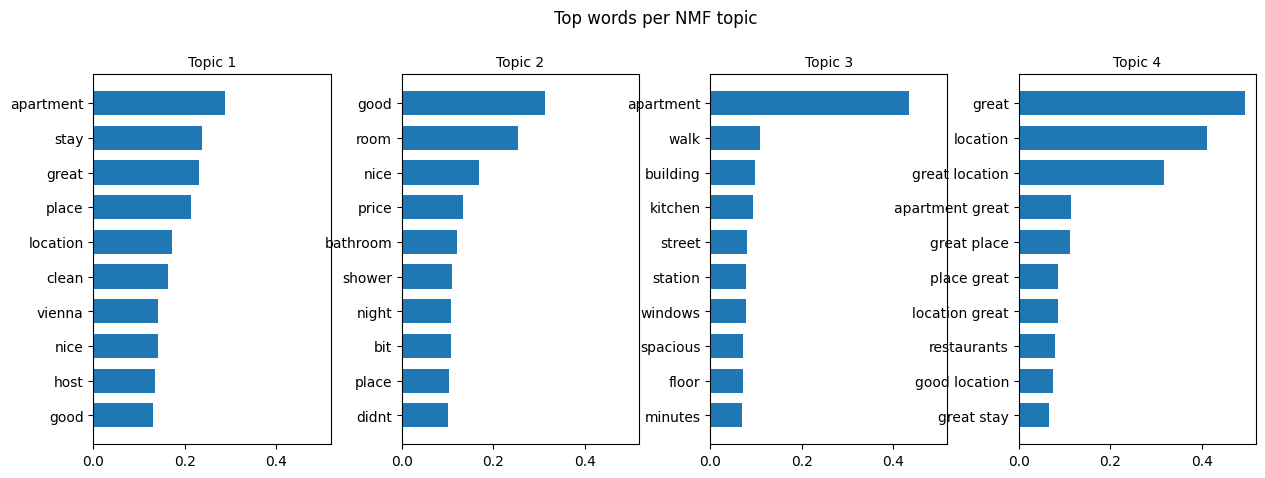

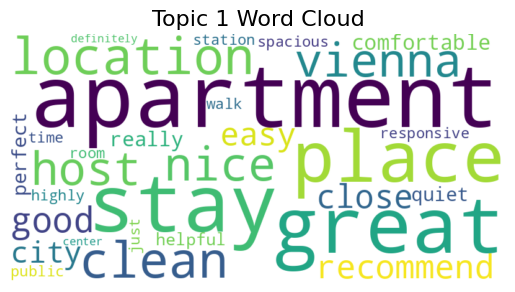

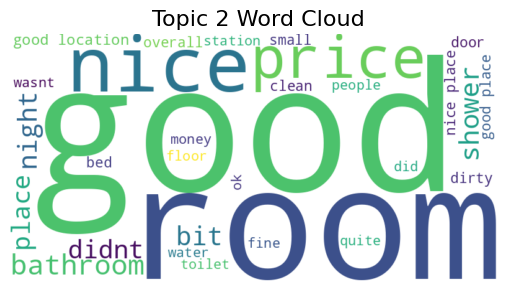

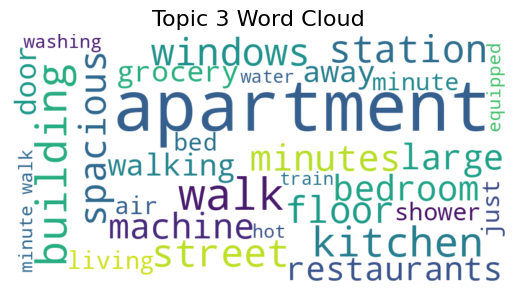

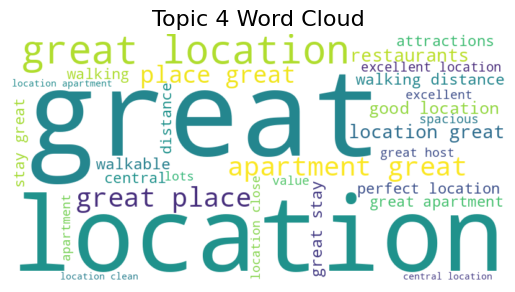

In [41]:
# LSA topic plots

plot_top_words(lsa_model, terms, n_top_words=10, title='Top words per NMF topic')
plot_word_clouds(lsa_model, terms)

In [42]:
#Let's check the topic distance

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Function to plot topic distances using PCA
def plot_topic_distance_pca(model, title='Topic Distance (PCA)'):
    # Get the topic-word matrix (components_) from the model
    topic_word_matrix = model.components_

    # Apply PCA to reduce the topic-word matrix to 2 dimensions
    pca = PCA(n_components=2)
    topic_pca = pca.fit_transform(topic_word_matrix)

    # Plot the topics in 2D space
    plt.figure(figsize=(8, 6))
    plt.scatter(topic_pca[:, 0], topic_pca[:, 1], c='blue', edgecolor='k', s=100)

    # Annotate the topics with text labels
    for i in range(len(topic_pca)):
        plt.text(topic_pca[i, 0], topic_pca[i, 1], f'Topic {i+1}', fontsize=12)

    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.show()

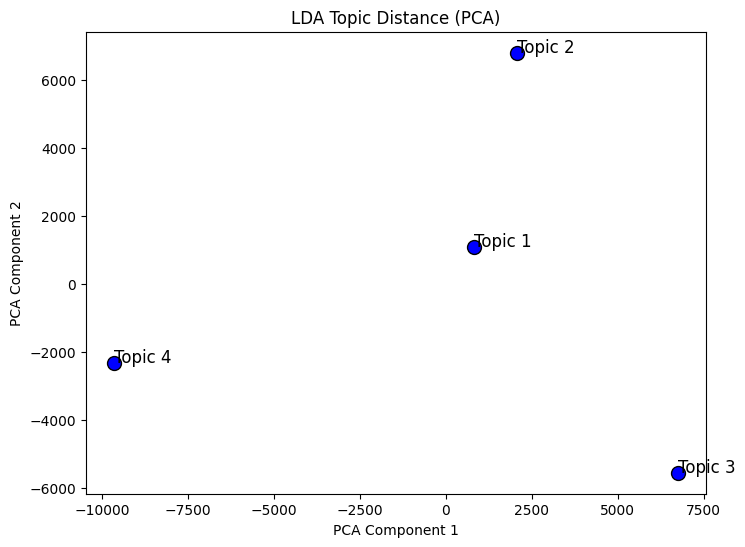

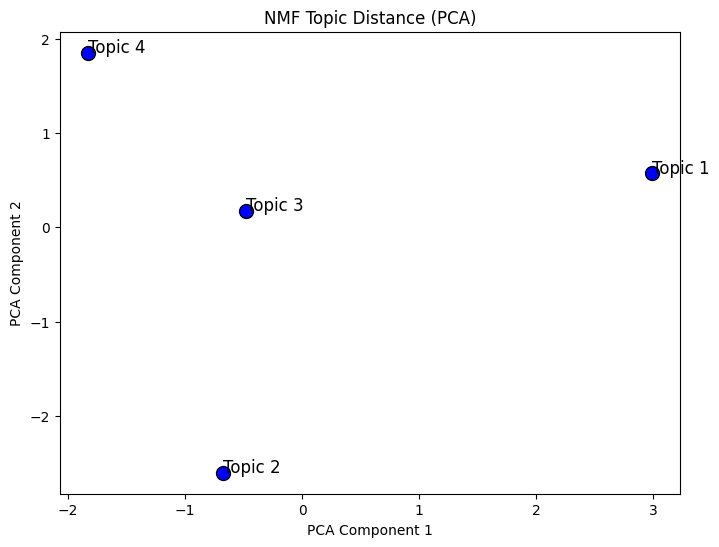

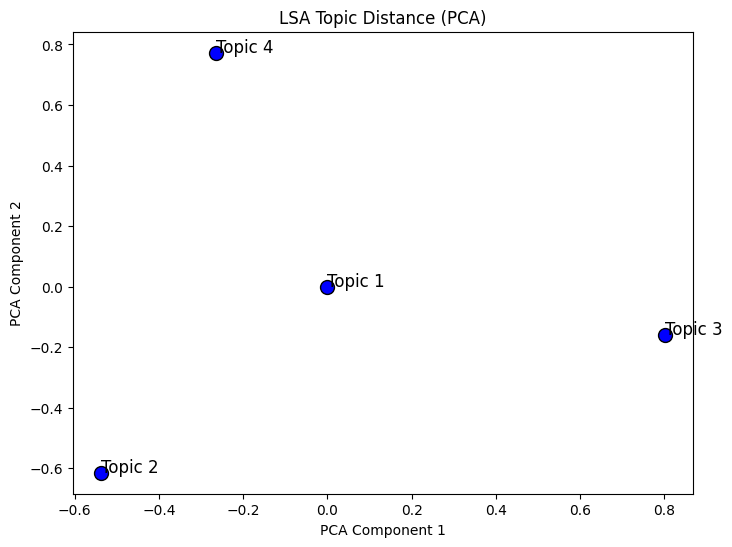

In [43]:
# compare topic distance of all models

# LDA
plot_topic_distance_pca(lda_model, title='LDA Topic Distance (PCA)')
# NMF
plot_topic_distance_pca(nmf_model, title='NMF Topic Distance (PCA)')
# LSA
plot_topic_distance_pca(lsa_model, title='LSA Topic Distance (PCA)')


NMF produced the most distinct and interpretable topics.

The four topics can be summarized as:

1. **Walkability & Local Amenities** — walking distance, grocery stores, restaurants, and nearby conveniences.
2. **Property Condition / Issues** — bathroom, shower, bed, window, and other property-condition mentions.
3. **Transport & Accessibility** — public transport, stations, metro, and ease of getting around.
4. **Host & Hospitality** — friendly, helpful, wonderful, and home-like experiences.

In [44]:
# Assign NMF topic weights to each listing
topic_model = nmf_model.transform(X_tfidf)

In [45]:
listing_topics = pd.DataFrame(
    topic_model,
    columns=[
    "walkability_local",
    "property_condition",
    "transport_access",
    "host_hospitality"
    ]
)

listing_topics["listing_id"] = merged_df["listing_id"].reset_index(drop=True)

listing_topics.head()

,walkability_local,property_condition,transport_access,host_hospitality,listing_id
0,0.069255,0.022211,0.032847,0.037724,40625
1,0.048725,0.042158,0.047198,0.061921,51287
2,0.050634,0.006993,0.065264,0.020179,109679
3,0.059422,0.029954,0.052901,0.054517,114505
4,0.034026,0.011870,0.079300,0.050628,169672


In [46]:
topic_sums = listing_topics[
    ["walkability_local",
    "property_condition",
    "transport_access",
    "host_hospitality"
    ]
].sum()

print(topic_sums)

walkability_local     308.122392
property_condition    257.313874
transport_access      295.985098
host_hospitality      229.520515
dtype: float64


In [47]:
#Normalizing topic shares:
topic_distribution=topic_sums/topic_sums.sum()
print(topic_distribution)

walkability_local     0.282437
property_condition    0.235864
transport_access      0.271312
host_hospitality      0.210387
dtype: float64


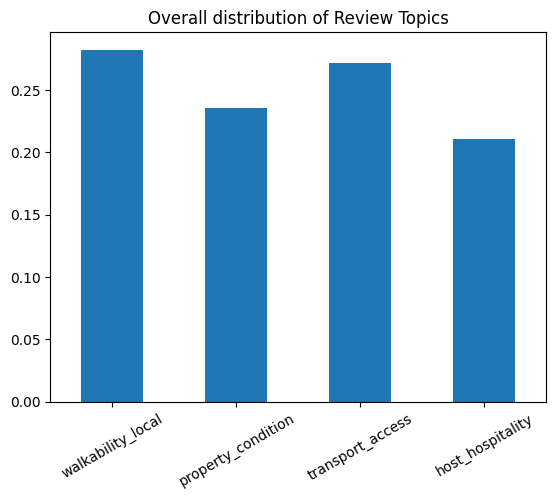

In [48]:
#Overall topic distribution
topic_distribution.plot(kind='bar', title="Overall distribution of Review Topics")
plt.xticks(rotation=30)
plt.show()

##Using pipeline for sentiment

### Sentiment Analysis

Review sentiment was estimated using a pretrained DistilBERT sentiment model.

Because transformer inference across the full review corpus is computationally expensive, sentiment scoring was performed once during preprocessing and the resulting listing-level sentiment scores were saved for reuse.

The analysis below loads these precomputed sentiment scores to keep the main notebook reproducible and efficient.

In [49]:
# import torch
# from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# tokenizer = DistilBertTokenizer.from_pretrained(
#     "distilbert-base-uncased-finetuned-sst-2-english"
# )
# model = DistilBertForSequenceClassification.from_pretrained(
#     "distilbert-base-uncased-finetuned-sst-2-english"
# )

# model.eval()

In [50]:
# def get_sentiment_batch(texts, batch_size=32):
#     results = []

#     for i in range(0, len(texts), batch_size):
#         batch = texts[i:i+batch_size]

#         inputs = tokenizer(
#             list(batch),
#             return_tensors="pt",
#             truncation=True,
#             padding=True,
#             max_length=512
#         )

#         with torch.no_grad():
#             logits = model(**inputs).logits

#         probs = torch.nn.functional.softmax(logits, dim=1)
#         scores = (probs[:,1] - probs[:,0]).tolist()

#         results.extend(scores)
#     return results

In [51]:
# texts=merged_df["cleaned_comments"].fillna("").tolist()
# merged_df["sentiment"] = get_sentiment_batch(texts, batch_size=16)

In [52]:
# listing_sentiment = (
#     merged_df.groupby("listing_id", as_index=False)["sentiment"]
#     .mean()
#     .rename(columns={"sentiment": "avg_sentiment"})
# )

In [53]:
# listing_sentiment.head()

In [54]:
# #saving cleaned dataset
# listing_sentiment.to_csv('listing_sentiment.csv', index=False)
# files.download('listing_sentiment.csv')

In [55]:
# Load precomputed listing-level sentiment scores from GitHub
sentiment_url = (
    "https://raw.githubusercontent.com/"
    "Onureeva/airbnb-vienna-nlp-pricing/main/"
    "data/listing_sentiment.csv"
)

listing_sentiment_df = pd.read_csv(sentiment_url)

print("Sentiment shape:", listing_sentiment_df.shape)
listing_sentiment_df.head()

Sentiment shape: (8139, 2)


,listing_id,avg_sentiment
0,40625,0.482805
1,51287,0.598834
2,109679,0.497315
3,114505,0.436749
4,169672,0.903126


In [56]:
listing_sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8139 entries, 0 to 8138
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     8139 non-null   int64  
 1   avg_sentiment  8139 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 127.3 KB


In [57]:
merged_df = pd.merge(
    merged_df,
    listing_sentiment_df,
    on="listing_id",
    how="left"
)

In [58]:
print("Rows:", len(merged_df))
print("Unique listings:", merged_df["listing_id"].nunique())
print("Missing sentiment:", merged_df["avg_sentiment"].isna().sum())

Rows: 8141
Unique listings: 8141
Missing sentiment: 3


In [59]:
missing_sentiment = merged_df[
    merged_df["avg_sentiment"].isna()
][["listing_id", "price", "room_type", "neighbourhood_cleansed"]]

missing_sentiment

,listing_id,price,room_type,neighbourhood_cleansed
5897,1162943646517101446,208,Entire home/apt,Alsergrund
6408,1255075749502561159,130,Entire home/apt,Meidling
8027,1478221274495498030,93,Private room,Innere Stadt


In [60]:
print(
    "Listings in merged_df but not in sentiment file:",
    set(merged_df["listing_id"]) - set(listing_sentiment_df["listing_id"])
)

Listings in merged_df but not in sentiment file: {1478221274495498030, 1162943646517101446, 1255075749502561159}


Three listings in the final merged dataset were not present in the previously cached sentiment file. Because this affected only 3 of 8,141 listings (<0.04% of the sample), these observations were excluded rather than rerunning the full transformer inference pipeline.

In [61]:
# Keep only listings with available precomputed sentiment
merged_df = merged_df.dropna(subset=["avg_sentiment"]).copy()

print("Rows after sentiment alignment:", len(merged_df))
print("Unique listings:", merged_df["listing_id"].nunique())
print("Missing sentiment:", merged_df["avg_sentiment"].isna().sum())

Rows after sentiment alignment: 8138
Unique listings: 8138
Missing sentiment: 0


<Axes: >

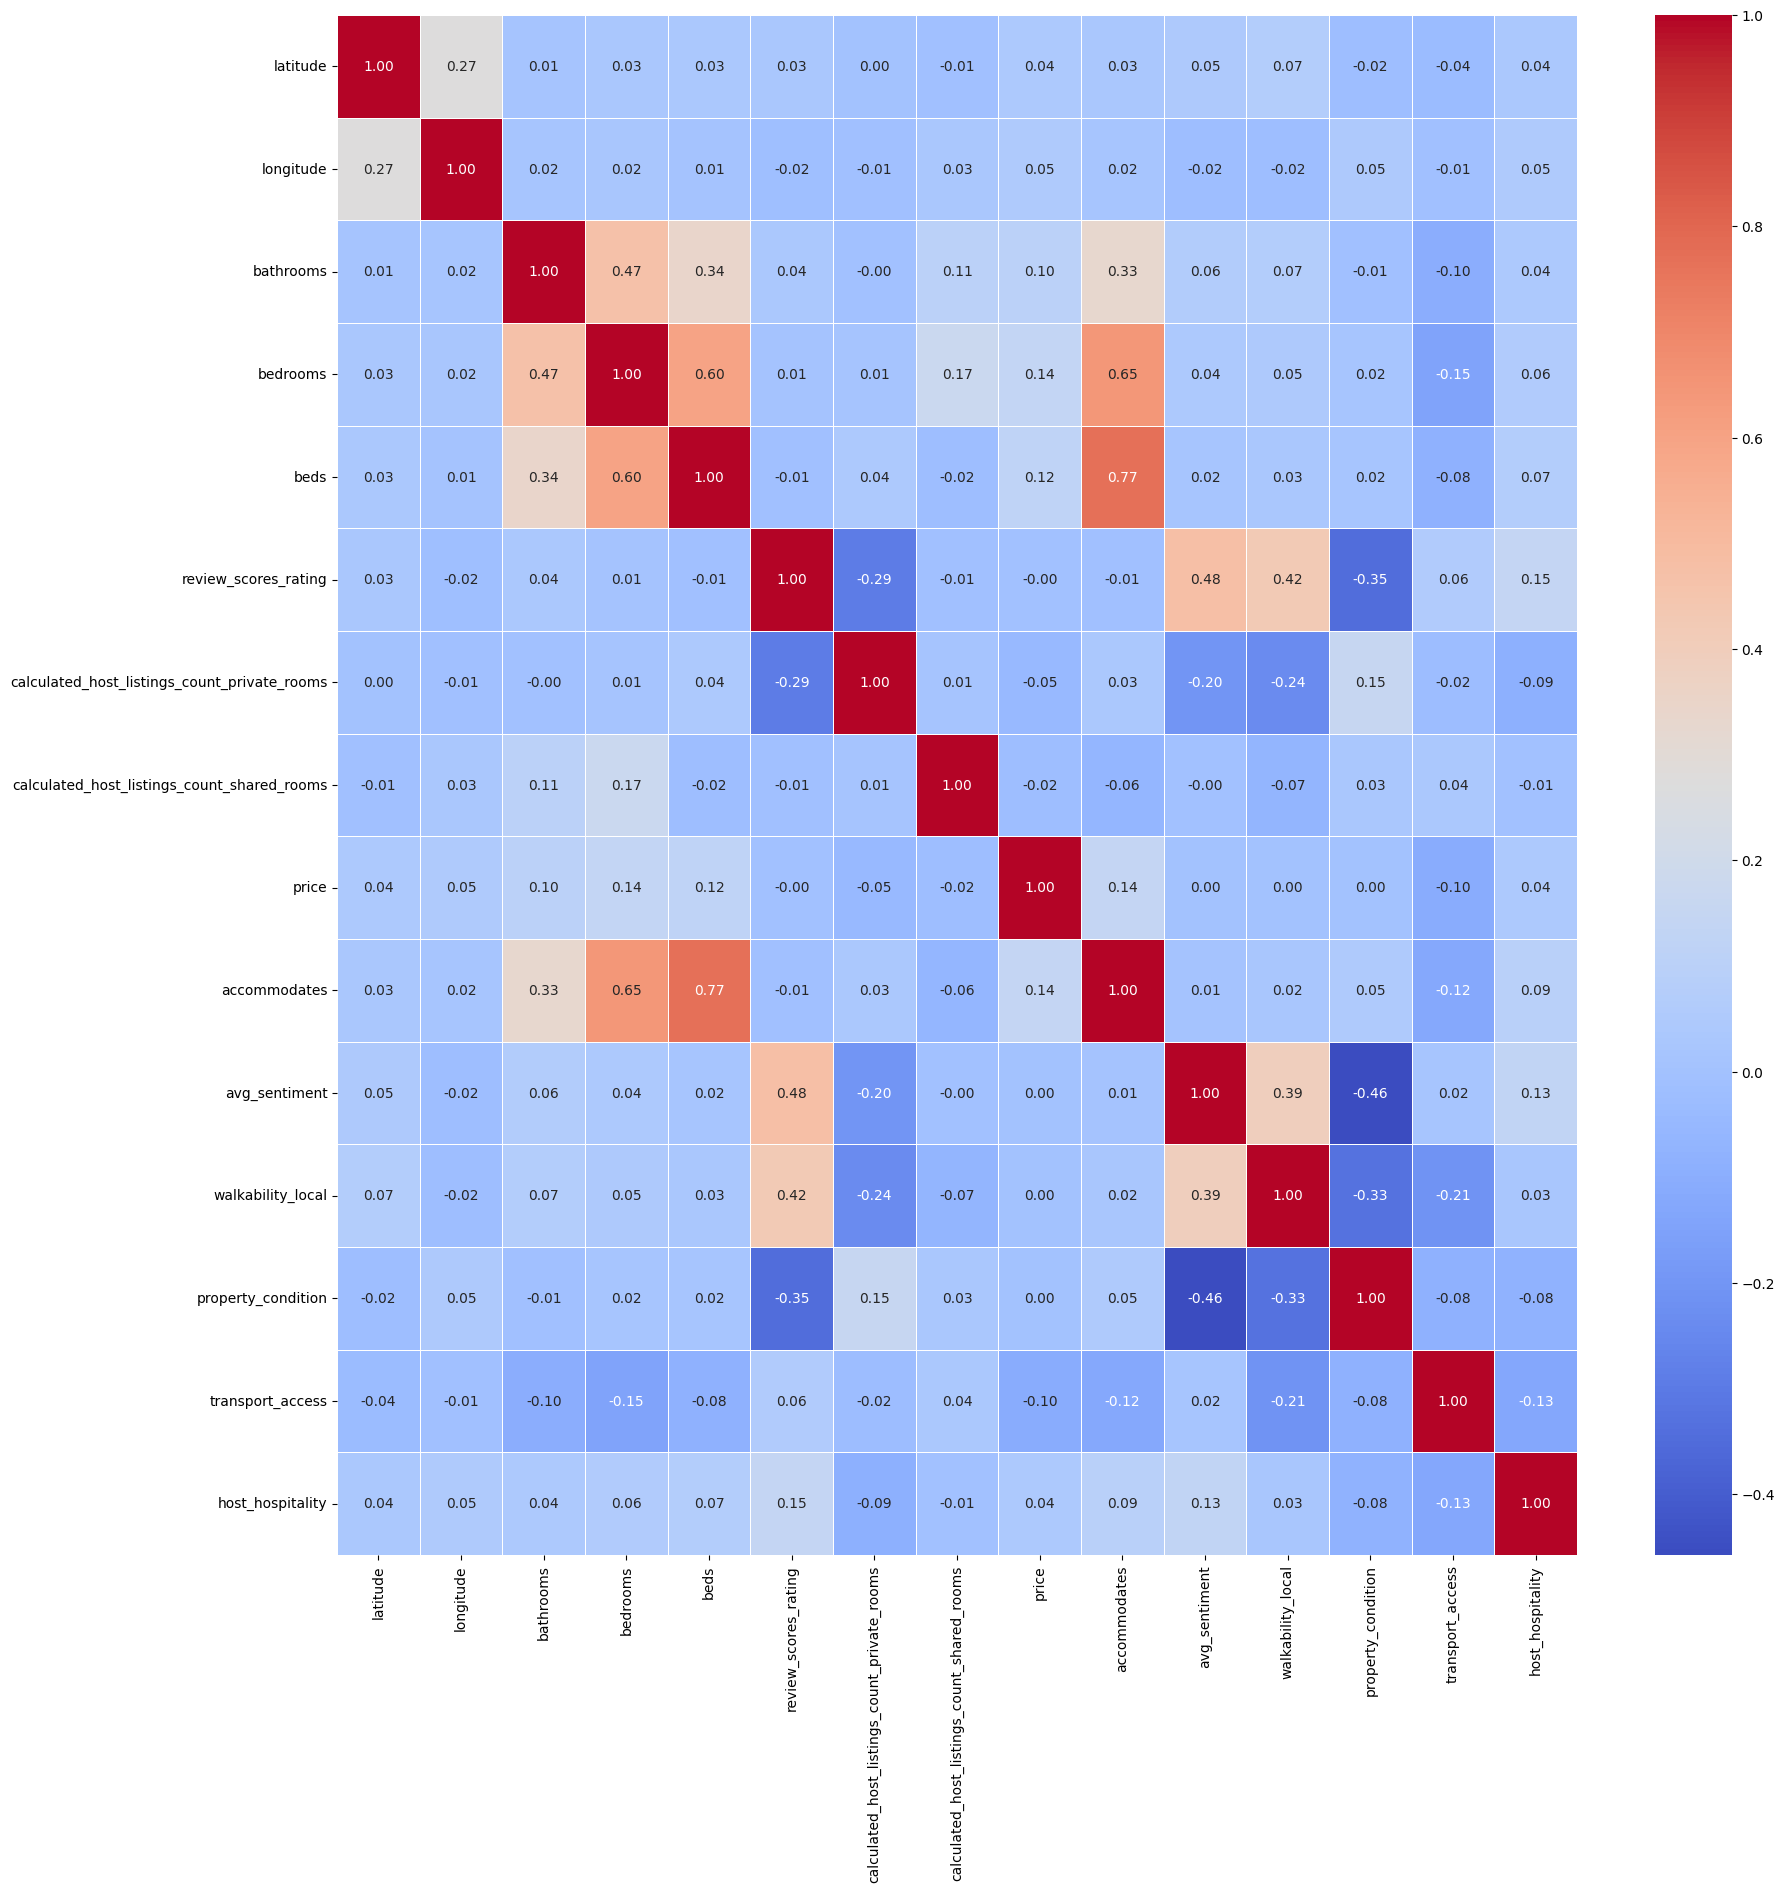

In [62]:
merged_df = pd.merge(merged_df, listing_topics, on='listing_id', how='left')
#Generating a correlation heatmap with the undropped columns AND SENTIMENT
num_cols = ['latitude', 'longitude', 'bathrooms', 'bedrooms', 'beds',
'review_scores_rating',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'price','accommodates',
'avg_sentiment',
"walkability_local",
"property_condition",
"transport_access",
"host_hospitality"]

#Generating a correlation heatmap
fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(merged_df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=.5, ax=ax, fmt='.2f')

From the correlation heatmap, review length doesn't appear to have any even slightly strong correlations.
However, avg_sentiment has a 0.51 correlation with review_scores_rating, which would be expected as a higher score would come from a more positive sentiment.
#
Additionally, there are two weak, but present negative correlations with availability and the host's calculated number of private listings. A place perceived negatively may get more customers and thus be perceived more negatively, but it's interesting that this appears for the number of private rooms. This shows up slightly more strongly (-0.3) with the reveiw scores rating. **One explanation may be that with more listings, the host gives less attention and care to each, or is less able to communicate effectively with the guests.**


# EDA - Merged Dataset

In [63]:
merged_df.shape

(8138, 26)

In [64]:
merged_df.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'amenities', 'price', 'first_review', 'last_review',
       'review_scores_rating', 'instant_bookable',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'listing_id',
       'combined_reviews', 'comments_clean', 'comments_soft', 'avg_sentiment',
       'walkability_local', 'property_condition', 'transport_access',
       'host_hospitality'],
      dtype='object')

In [65]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8138 entries, 0 to 8137
Data columns (total 26 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   neighbourhood_cleansed                        8138 non-null   object 
 1   latitude                                      8138 non-null   float64
 2   longitude                                     8138 non-null   float64
 3   property_type                                 8138 non-null   object 
 4   room_type                                     8138 non-null   object 
 5   accommodates                                  8138 non-null   int64  
 6   bathrooms                                     8138 non-null   float64
 7   bedrooms                                      8138 non-null   float64
 8   beds                                          8138 non-null   float64
 9   amenities                                     8138 non-null   o

### Price Distribution

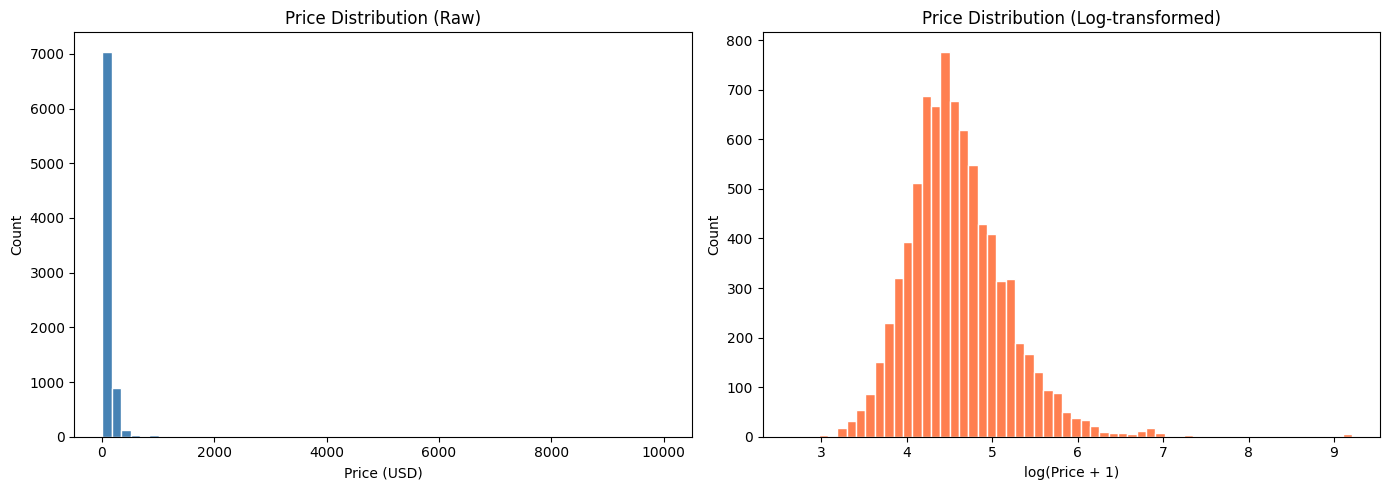

Price stats:
count     8138.000000
mean       126.780782
std        290.062821
min         13.000000
25%         66.000000
50%         91.000000
75%        135.000000
max      10000.000000
Name: price, dtype: float64

Listings with price > $500: 88


In [66]:
# Checking the Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
axes[0].hist(merged_df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

# Log transformed price to handle extreme outliers
axes[1].hist(np.log1p(merged_df['price']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Price stats:\n{merged_df['price'].describe()}")
print(f"\nListings with price > $500: {(merged_df['price'] > 500).sum()}")

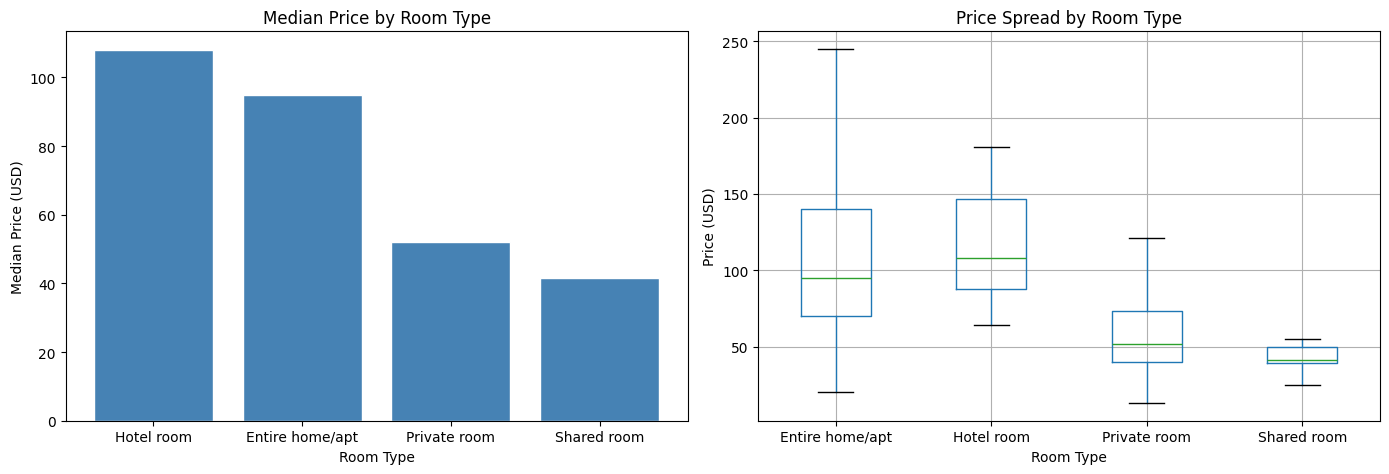

In [67]:
# Price by Room Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_avg = merged_df.groupby('room_type')['price'].median().sort_values(ascending=False)

axes[0].bar(room_avg.index, room_avg.values, color='steelblue', edgecolor='white')
axes[0].set_title('Median Price by Room Type')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Median Price (USD)')

# Boxplot to show spread
merged_df.boxplot(column='price', by='room_type', ax=axes[1],
                  showfliers=False)  # showfliers=False hides extreme outliers for readability
axes[1].set_title('Price Spread by Room Type')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Price (USD)')
plt.suptitle('')  # removes the default pandas boxplot title

plt.tight_layout()
plt.show()

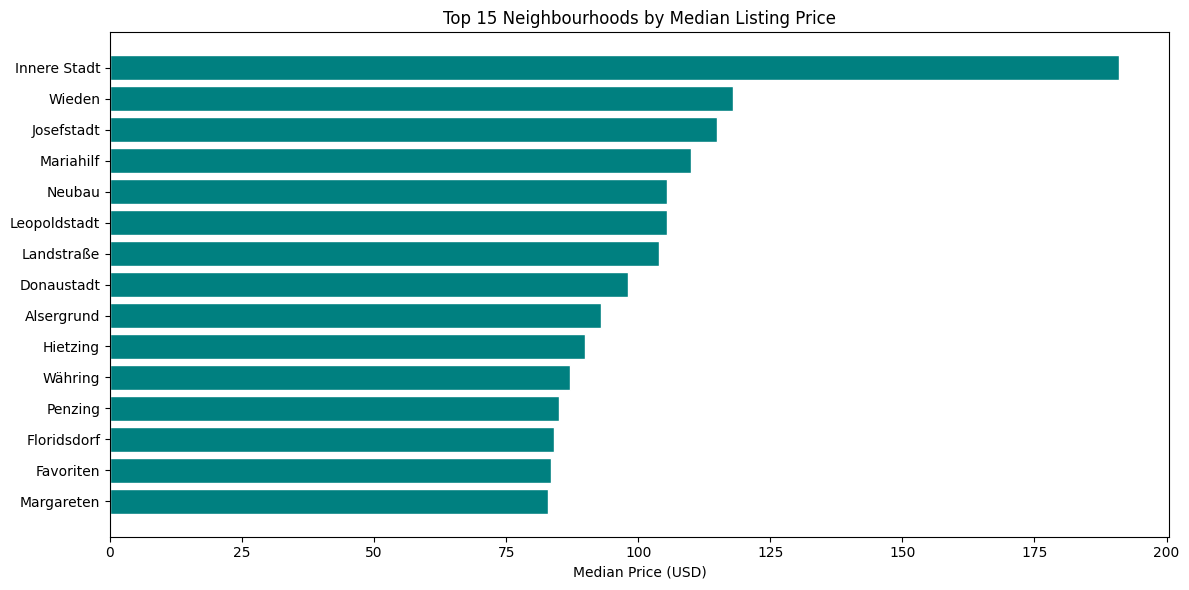

In [68]:
#Top Neighbourhoods by Median Price
top_neighbourhoods = (
    merged_df.groupby('neighbourhood_cleansed')['price']
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
plt.barh(top_neighbourhoods.index[::-1], top_neighbourhoods.values[::-1], color='teal', edgecolor='white')
plt.title('Top 15 Neighbourhoods by Median Listing Price')
plt.xlabel('Median Price (USD)')
plt.tight_layout()
plt.show()

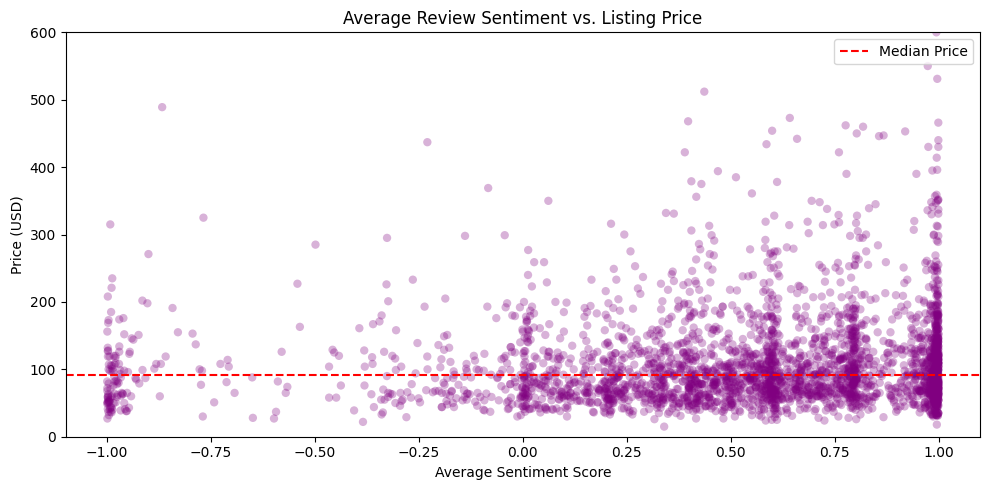

Correlation between sentiment and price: 0.003


In [69]:
# Sentiment vs Price
# Using a sample so the plot isn't overloaded with 58,500 points
sample = merged_df.sample(3000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['avg_sentiment'], sample['price'], alpha=0.3, color='purple', edgecolor='none')
plt.title('Average Review Sentiment vs. Listing Price')
plt.xlabel('Average Sentiment Score')
plt.ylabel('Price (USD)')
plt.ylim(0, 600)  # cap y-axis so outliers don't compress the main data
plt.axhline(merged_df['price'].median(), color='red', linestyle='--', label='Median Price')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Correlation between sentiment and price: {merged_df['avg_sentiment'].corr(merged_df['price']):.3f}")

## Feature Engineering

In [70]:
# Prepare modeling dataset
model_df = merged_df.copy()

model_df["amenity_count"] = model_df["amenities"].apply(
    lambda x: len(x.split(",")) if isinstance(x, str) else 0
)

model_df["instant_bookable"] = (
    model_df["instant_bookable"] == "t"
).astype(int)

cols_to_drop = [
    "listing_id",
    "combined_reviews",
    "comments_clean",
    "comments_soft",
    "cleaned_comments",
    "first_review",
    "last_review",
    "amenities"
]

model_df.drop(
    columns=cols_to_drop,
    inplace=True,
    errors="ignore"
)

model_df = pd.get_dummies(
    model_df,
    columns=[
        "room_type",
        "neighbourhood_cleansed",
        "property_type"
    ],
    drop_first=True
)

print("Modeling dataset shape:", model_df.shape)

Modeling dataset shape: (8138, 82)


In [71]:
print(model_df.shape)
print(model_df.select_dtypes(exclude=np.number).columns.tolist())

(8138, 82)
['room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_cleansed_Brigittenau', 'neighbourhood_cleansed_Donaustadt', 'neighbourhood_cleansed_Döbling', 'neighbourhood_cleansed_Favoriten', 'neighbourhood_cleansed_Floridsdorf', 'neighbourhood_cleansed_Hernals', 'neighbourhood_cleansed_Hietzing', 'neighbourhood_cleansed_Innere Stadt', 'neighbourhood_cleansed_Josefstadt', 'neighbourhood_cleansed_Landstraße', 'neighbourhood_cleansed_Leopoldstadt', 'neighbourhood_cleansed_Liesing', 'neighbourhood_cleansed_Margareten', 'neighbourhood_cleansed_Mariahilf', 'neighbourhood_cleansed_Meidling', 'neighbourhood_cleansed_Neubau', 'neighbourhood_cleansed_Ottakring', 'neighbourhood_cleansed_Penzing', 'neighbourhood_cleansed_Rudolfsheim-Fünfhaus', 'neighbourhood_cleansed_Simmering', 'neighbourhood_cleansed_Wieden', 'neighbourhood_cleansed_Währing', 'property_type_Entire bungalow', 'property_type_Entire chalet', 'property_type_Entire condo', 'property_type_Entir

## Test Train Split

In [72]:
nlp_features = [
    "avg_sentiment",
    "walkability_local",
    "property_condition",
    "transport_access",
    "host_hospitality"
]

structural_features = [
    col for col in model_df.columns
    if col not in nlp_features + ["price", "log_price"]
]

In [73]:
print(f"Structural features: {len(structural_features)}")
print(f"NLP features: {len(nlp_features)}")

Structural features: 76
NLP features: 5


In [74]:
# Target variable
model_df["log_price"] = np.log1p(model_df["price"])

# Train/test split by row index
train_idx, test_idx = train_test_split(
    model_df.index,
    test_size=0.2,
    random_state=42
)

y_train = model_df.loc[train_idx, "log_price"]
y_test = model_df.loc[test_idx, "log_price"]

# Structural features only
X_struct_train = model_df.loc[
    train_idx,
    structural_features
]

X_struct_test = model_df.loc[
    test_idx,
    structural_features
]

# Structural + NLP features
all_features = structural_features + nlp_features

X_all_train = model_df.loc[
    train_idx,
    all_features
]

X_all_test = model_df.loc[
    test_idx,
    all_features
]

In [75]:
print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Structural features:", X_struct_train.shape[1])
print("All features:", X_all_train.shape[1])


Train rows: 6510
Test rows: 1628
Structural features: 76
All features: 81


##Modeling

###Model 1: Structural Features Only

In [76]:
from sklearn.linear_model import Ridge

# Standardize structural features
scaler_struct = StandardScaler()

X_struct_train_scaled = scaler_struct.fit_transform(
    X_struct_train
)

X_struct_test_scaled = scaler_struct.transform(
    X_struct_test
)

# Ridge model: structural features only
ridge_struct = Ridge(alpha=1.0)

ridge_struct.fit(
    X_struct_train_scaled,
    y_train
)

pred_struct_log = ridge_struct.predict(
    X_struct_test_scaled
)

### Model 2: Structural + NLP Features

In [77]:
scaler_all = StandardScaler()

X_all_train_scaled = scaler_all.fit_transform(
    X_all_train
)

X_all_test_scaled = scaler_all.transform(
    X_all_test
)

ridge_all = Ridge(alpha=1.0)

ridge_all.fit(
    X_all_train_scaled,
    y_train
)

pred_all_log = ridge_all.predict(
    X_all_test_scaled
)

### Baseline Model

In [78]:
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score
)
# Convert log-transformed prices back to dollar values
actual_prices = np.expm1(y_test)

median_train_price = np.median(
    np.expm1(y_train)
)

median_predictions = np.full(
    len(y_test),
    median_train_price
)

baseline_mae = mean_absolute_error(
    actual_prices,
    median_predictions
)

baseline_medae = median_absolute_error(
    actual_prices,
    median_predictions
)

print("Median baseline")
print(f"MAE: ${baseline_mae:.2f}")
print(f"Median absolute error: ${baseline_medae:.2f}")

Median baseline
MAE: $80.06
Median absolute error: $30.00


### Model Evaluation

In [79]:
def evaluate_price_model(
    name,
    y_true_log,
    y_pred_log
):
    actual = np.expm1(y_true_log)
    predicted = np.expm1(y_pred_log)

    return {
        "Model": name,
        "R2_log": r2_score(
            y_true_log,
            y_pred_log
        ),
        "MAE_dollars": mean_absolute_error(
            actual,
            predicted
        ),
        "Median_AE_dollars": median_absolute_error(
            actual,
            predicted
        ),
        "RMSE_dollars": np.sqrt(
            mean_squared_error(actual, predicted)
        )
    }

In [80]:
results = [
    {
        "Model": "Median baseline",
        "R2_log": np.nan,
        "MAE_dollars": baseline_mae,
        "Median_AE_dollars": baseline_medae,
        "RMSE_dollars": np.sqrt(
            mean_squared_error(
                actual_prices,
                median_predictions
            )
        )
    },
    evaluate_price_model(
        "Structural only",
        y_test,
        pred_struct_log
    ),
    evaluate_price_model(
        "Structural + NLP",
        y_test,
        pred_all_log
    )
]

results_df = pd.DataFrame(results)

display(results_df)

,Model,R2_log,MAE_dollars,Median_AE_dollars,RMSE_dollars
0,Median baseline,NaN,80.059582,30.000000,495.754843
1,Structural only,0.380916,66.829936,21.327170,488.843682
2,Structural + NLP,0.410424,65.843979,21.484806,488.171942


### Model comparison — key takeaway

Adding NLP features from recent guest reviews improved model performance, but only modestly:

- MAE decreased from approximately 66.83 to 65.84 USD
- R² on log-price increased from 0.381 to 0.410
- The MAE improvement was approximately 0.99 USD

This suggests that guest-review text contains some incremental pricing signal, but most price variation is still explained by structured listing characteristics. Reviews may therefore be more valuable for understanding guest expectations and market positioning than for direct price prediction.

In [81]:
# Quantify the incremental value of NLP features
mae_struct = results_df.loc[1, "MAE_dollars"]
mae_all = results_df.loc[2, "MAE_dollars"]
r2_struct = results_df.loc[1, "R2_log"]
r2_all = results_df.loc[2, "R2_log"]

mae_struct = results_df.loc[1, "MAE_dollars"]
mae_all = results_df.loc[2, "MAE_dollars"]

r2_struct = results_df.loc[1, "R2_log"]
r2_all = results_df.loc[2, "R2_log"]


print(f"MAE improvement: ${mae_struct - mae_all:.2f}")
print(f"R² improvement: {r2_all - r2_struct:.2f}")

MAE improvement: $0.99
R² improvement: 0.03


In [82]:
coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": ridge_all.coef_
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df.head(15)

,feature,coefficient,abs_coefficient
45,property_type_Entire rental unit,0.146123,0.146123
2,accommodates,0.116620,0.116620
79,transport_access,-0.101822,0.101822
4,bedrooms,0.097523,0.097523
46,property_type_Entire serviced apartment,0.097435,0.097435
8,calculated_host_listings_count_private_rooms,-0.089209,0.089209
38,property_type_Entire condo,0.087829,0.087829
21,neighbourhood_cleansed_Innere Stadt,0.087718,0.087718
7,instant_bookable,0.069247,0.069247
32,neighbourhood_cleansed_Rudolfsheim-Fünfhaus,-0.065148,0.065148


**property_type_Entire rental unit** appears to be the strongest positive predictor of price in the Ridge model. Entire rental units tend to be associated with higher prices than the reference property type.

**accommodates** is also positively associated with price. Listings that can accommodate more guests tend to have higher prices.

**transport_access** is one of the strongest NLP-related features and has a negative coefficient. This suggests that listings whose reviews place greater emphasis on transport and accessibility tend to be associated with lower prices, holding the other model features constant.

**bedrooms** also has a positive relationship with price: listings with more bedrooms tend to be more expensive.

# 6. Price Segment & Guest Expectation Analysis

In [83]:
segment_df = merged_df.copy()

bins = [0, 75, 125, 200, 500, np.inf]

labels = [
    "Budget",
    "Standard",
    "Premium",
    "High-end",
    "Luxury"
]

segment_df["price_segment"] = pd.cut(
    segment_df["price"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [84]:
segment_df.groupby(
    "price_segment",
    observed=True
)["price"].agg(["count", "min", "median", "max"])

,count,min,median,max
price_segment,,,,
Budget,2833,13,59.0,75
Standard,2975,76,95.0,125
Premium,1526,126,153.0,200
High-end,716,201,255.5,500
Luxury,88,502,877.5,10000


(0.0, 500.0)

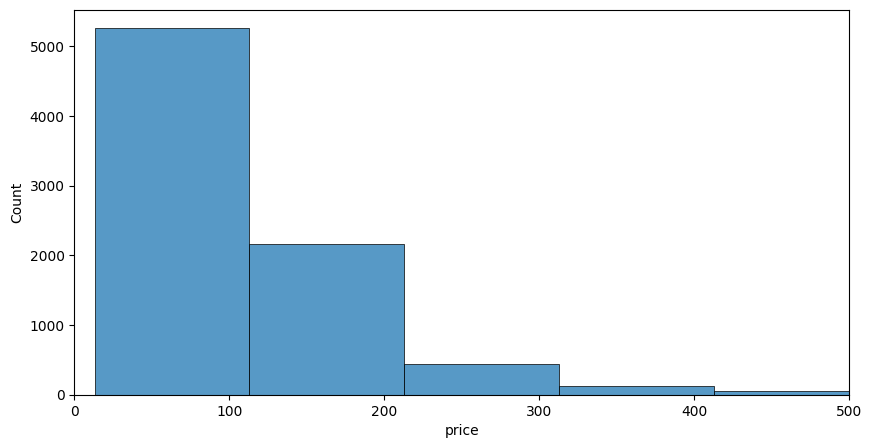

In [85]:
plt.figure(figsize=(10,5))
sns.histplot(segment_df["price"], bins=100)
plt.xlim(0,500)

In [86]:
segment_df["price"].quantile(
    [0.8,0.9,0.95,0.99]
)

,price
0.80,151.00
0.90,200.00
0.95,268.15
0.99,524.41


In [87]:
topic_cols = [
    "walkability_local",
    "property_condition",
    "transport_access",
    "host_hospitality"
]


topic_by_segment = (
    segment_df
    .groupby(
        "price_segment",
        observed=True
    )[topic_cols]
    .mean()
)

display(topic_by_segment)

,walkability_local,property_condition,transport_access,host_hospitality
price_segment,,,,
Budget,0.032870,0.034943,0.045051,0.023271
Standard,0.040724,0.029230,0.036520,0.027185
Premium,0.039916,0.029861,0.027814,0.033597
High-end,0.041859,0.031675,0.020821,0.039839
Luxury,0.033575,0.035005,0.025861,0.033163


In [88]:
overall = segment_df[topic_cols].mean()

topic_index = (
    topic_by_segment
    .divide(overall)
    *100
)

display(topic_index.round(1))

,walkability_local,property_condition,transport_access,host_hospitality
price_segment,,,,
Budget,86.8,110.5,123.9,82.5
Standard,107.6,92.5,100.4,96.4
Premium,105.4,94.5,76.5,119.1
High-end,110.6,100.2,57.3,141.3
Luxury,88.7,110.7,71.1,117.6


Topic emphasis varies clearly across price segments. Budget listings show substantially higher-than-average transport-related review content, while premium and high-end listings show stronger emphasis on host hospitality. Luxury listings also show above-average emphasis on property condition and hospitality. These results suggest that the content of guest reviews shifts systematically across market segments.

In [89]:
segment_df["dominant_topic"] = (
    segment_df[topic_cols]
    .idxmax(axis=1)
)

dominant = pd.crosstab(
    segment_df["price_segment"],
    segment_df["dominant_topic"],
    normalize="index"
)*100

display(dominant.round(1))

dominant_topic,host_hospitality,property_condition,transport_access,walkability_local
price_segment,,,,
Budget,9.2,26.9,38.8,25.1
Standard,13.4,21.0,28.5,37.1
Premium,20.6,23.1,19.6,36.8
High-end,29.1,22.6,13.3,35.1
Luxury,22.7,30.7,20.5,26.1


The dominant-topic analysis reinforces the segment-level pattern. Transport and accessibility is the most common dominant review topic among Budget listings (38.8%), but its prevalence declines substantially in higher-priced segments. Host hospitality becomes more prominent in Premium and High-end listings, while Luxury listings show a more balanced topic mix, with property condition appearing most frequently as the dominant topic.

These percentages represent the topic with the highest NMF weight for each listing; they should not be interpreted as direct measures of guest preferences.

In [90]:
segment_df.groupby(
    "price_segment",
    observed=True
)["avg_sentiment"].mean()

,avg_sentiment
price_segment,
Budget,0.452465
Standard,0.534180
Premium,0.544833
High-end,0.612620
Luxury,0.496563


In [91]:
from scipy.stats import kruskal


kruskal_results = []

for topic in topic_cols:

    groups = [
        group[topic].dropna().values
        for _, group in segment_df.groupby(
            "price_segment",
            observed=True
        )
    ]

    h_stat, p_value = kruskal(*groups)

    kruskal_results.append({
        "topic": topic,
        "H_statistic": h_stat,
        "p_value": p_value
    })

kruskal_df = pd.DataFrame(kruskal_results)

display(kruskal_df)

,topic,H_statistic,p_value
0,walkability_local,173.823896,1.580041e-36
1,property_condition,55.446730,2.618972e-11
2,transport_access,786.639072,6.016502e-169
3,host_hospitality,288.762118,2.874820e-61


In [92]:
from statsmodels.stats.multitest import multipletests

kruskal_df["p_adjusted"] = multipletests(
    kruskal_df["p_value"],
    method="holm"
)[1]

kruskal_df["significant"] = (
    kruskal_df["p_adjusted"] < 0.05
)

display(kruskal_df)

,topic,H_statistic,p_value,p_adjusted,significant
0,walkability_local,173.823896,1.580041e-36,3.160083e-36,True
1,property_condition,55.446730,2.618972e-11,2.618972e-11,True
2,transport_access,786.639072,6.016502e-169,2.406601e-168,True
3,host_hospitality,288.762118,2.874820e-61,8.624461e-61,True


To test whether review topics differed across Airbnb price segments, I used the Kruskal–Wallis test. I chose it because I was comparing multiple groups and did not want to assume a normal distribution.

The results showed statistically significant differences for all four topics, even after applying the Holm correction for multiple testing.

The strongest difference across price segments was for transport and accessibility, followed by host hospitality and walkability. Property condition showed the smallest difference, although it was still statistically significant.

This does not mean that transport is necessarily the most important topic for price. It means that the distribution of transport-related review content varies the most across the different price segments.

Review topics differ significantly across Airbnb price segments (Kruskal–Wallis, Holm-adjusted p < 0.001 for all topics).

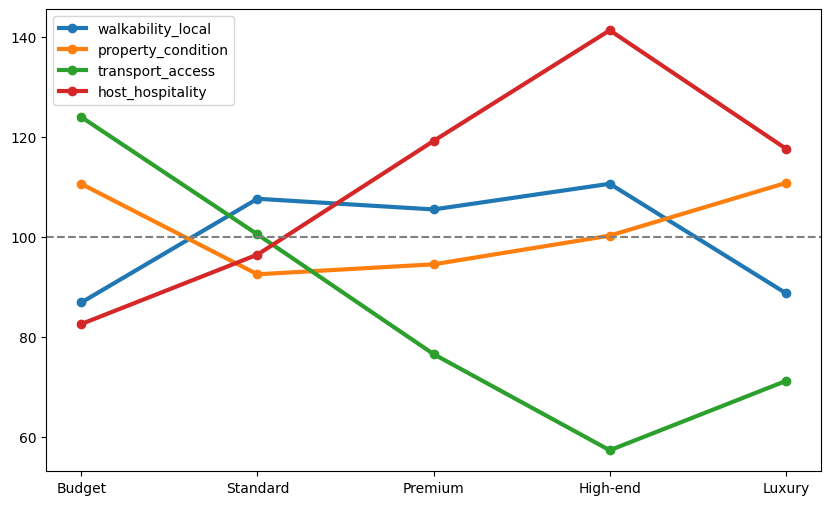

In [93]:
plt.figure(figsize=(10,6))

for col in topic_index.columns:
    plt.plot(
        topic_index.index,
        topic_index[col],
        marker='o',
        linewidth=3,
        label=col
    )

plt.axhline(
    100,
    color='gray',
    linestyle='--'
)

plt.legend()

## Conclusions and Limitations

### Key Findings

The analysis shows that the relative emphasis of review topics differs across Airbnb price segments. Topics such as transportation access, property condition, walkability/local area, and host hospitality are not equally prominent across price tiers, suggesting that guest-review content varies by market segment.

For price prediction, structural listing characteristics remain substantially more informative than review-derived NLP features. Adding the review-topic features improved model performance by approximately 0.03 in R². This indicates that review text provides additional predictive information, but the improvement is modest compared with the explanatory power of listing attributes such as location, room type, capacity, and amenities.

The best-performing model achieved an R² of approximately 0.40. Therefore, the model explains about 40% of the observed variation in listing prices, while roughly 60% remains unexplained by the variables included in this analysis.

### Practical Implications

The results suggest that hosts may benefit from emphasizing different aspects of their listings depending on their price segment. At the same time, review-derived insights should be treated as complementary to, rather than a replacement for, traditional listing characteristics when explaining or predicting Airbnb prices.

### Limitations

- The analysis is based on a single city, so the findings may not generalize to other Airbnb markets.
- The dataset represents one snapshot in time and does not capture seasonal or longitudinal changes in prices and guest preferences.
- The review topics simplify complex review text into a limited number of predefined themes.
- An R² of approximately 0.40 indicates that important determinants of price remain outside the current model, such as temporal demand, events, more detailed location effects, host pricing strategy, and other market conditions.
- The relationships identified in this project are associative and should not be interpreted as causal effects.
- TF-IDF and topic extraction were performed on the full review corpus before the train/test split. Although price was not used to construct these text features, a stricter predictive pipeline would fit the text transformations on the training data only.

Saving datasets for Tableau dashboards

In [94]:
segment_df.to_csv(
    "airbnb_segment_analysis.csv",
    index=False
)

In [95]:
topic_tableau = (
    topic_index
    .reset_index()
    .melt(
        id_vars="price_segment",
        var_name="topic",
        value_name="topic_index"
    )
)

In [96]:
topic_tableau["topic"] = topic_tableau["topic"].replace({
    "walkability_local": "Walkability & Local Amenities",
    "property_condition": "Property Condition",
    "transport_access": "Transport & Accessibility",
    "host_hospitality": "Host & Hospitality"
})

In [97]:
topic_tableau.head()

,price_segment,topic,topic_index
0,Budget,Walkability & Local Amenities,86.817948
1,Standard,Walkability & Local Amenities,107.562347
2,Premium,Walkability & Local Amenities,105.427336
3,High-end,Walkability & Local Amenities,110.559942
4,Luxury,Walkability & Local Amenities,88.678821


In [98]:
topic_tableau.to_csv(
    "topic_by_price_segment.csv",
    index=False
)

In [99]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)